# Recherche locale

CSI 4106 - automne 2026

Marcel Turcotte  
Version: août 9, 2026 12h46

# Préambule

## Message du jour

![](https://media.nature.com/w1248/magazine-assets/d41586-025-03340-w/d41586-025-03340-w_51595896.jpg?as=webp)

[Universities are embracing AI: will students get smarter or stop
thinking?](https://www.nature.com/articles/d41586-025-03340-w), Nature
News, 2025-10-21.

## Objectifs d’apprentissage

- **Comprendre** le concept et l’application des algorithmes de
  recherche locale dans les problèmes d’optimisation.
- **Implémenter** et **analyser** l’algorithme de montée de colline
  (*hill climbing*), en reconnaissant ses limitations comme les maxima
  locaux et les plateaux.
- **Appliquer** des stratégies efficaces de représentation des états
  dans des problèmes comme les 8-Reines pour améliorer l’efficacité de
  la recherche.
- **Expliquer** comment le recuit simulé surmonte les optima locaux en
  acceptant probabilistiquement des états pires.
- **Analyser** l’influence de la température et de la différence
  d’énergie sur la probabilité d’acceptation dans le recuit simulé.
- **Reconnaître** l’application du recuit simulé dans la résolution de
  problèmes d’optimisation complexes comme le problème du voyageur de
  commerce.

Dans cette présentation, nous analyserons deux algorithmes de recherche
locale : la montée de colline et le recuit simulé. Notre but est
d’expliquer le concept de recherche locale et d’examiner les méthodes
permettant d’éviter les minima (ou maxima) locaux. Nous aborderons
rapidement la montée de colline, compte tenu de sa simplicité, et nous
consacrerons plus de temps au recuit simulé, un algorithme très utile.

# Introduction

## Contexte

- L’accent a été mis sur la recherche de **chemins** dans un **espace
  d’états**.
- Certains problèmes privilégient l’**état final** par rapport au
  chemin.
  - Conception de circuits intégrés
  - Ordonnancement d’atelier
  - Programmation automatique

L’importance du chemin par rapport à l’état final dépend de la nature du
problème. Par exemple, dans un problème d’itinéraire, le chemin est la
pièce d’information cruciale recherchée.

## Problème des 8-Reines

In [1]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np

def display_n_queens(board, width):
    n = len(board)

    # Créer un motif d'échiquier
    board_matrix = np.zeros((n, n))
    for row in range(n):
        for col in range(n):
            if (row + col) % 2 == 0:
                board_matrix[row, col] = 1  # Cases blanches
            else:
                board_matrix[row, col] = 0.5

    # Créer un colormap personnalisé : gris pour 0.5 et blanc pour 1
    cmap = ListedColormap(['lightgray', 'white'])

    # Créer le graphique
    fig, ax = plt.subplots(figsize=(width, width))
    ax.imshow(board_matrix, cmap=cmap, extent=(0, n, 0, n))

    # Ajouter les marqueurs de reine
    for col in range(n):
        row = board[col]
        ax.text(col + 0.5, n - row - 0.5, '♛', fontsize=32, ha='center', va='center', color='black')

    # Ajouter des lignes de grille
    ax.set_xticks(np.arange(n+1), minor=True)
    ax.set_yticks(np.arange(n+1), minor=True)
    ax.grid(which='minor', color='black', linestyle='-', linewidth=2)

    # Supprimer les étiquettes d'axes et les ticks
    ax.set_xticks([])
    ax.set_yticks([])
    ax.tick_params(axis='both', which='both', length=0)

    plt.title(f"Problème des {n} Reines")
    plt.show()

DRAFT = False

## Problème des 8-Reines

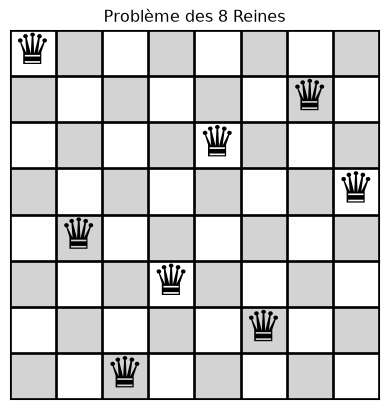

In [2]:
# Exemple de plateau pour le problème des 8-Reines
# Représente une solution valide
board = [0, 4, 7, 5, 2, 6, 1, 3]  

display_n_queens(board, 5)

Le **[problème des
8-Reines](https://fr.wikipedia.org/wiki/Problème_des_huit_dames)**
(8-Dames ou *8-Queens*) consiste à placer huit Reines sur un échiquier
de $8 \times 8$ de sorte qu’**aucune reine ne se menace**, c’est-à-dire
qu’aucune reine ne partage la même ligne, colonne ou diagonale.

Pour un échiquier de $8 \times 8$, il existe exactement 92 solutions
distinctes. En éliminant les solutions symmétrique, on se retrouve avec
12 solutions fondamentales. Dans le cas plus général d’un échiquier
$n \times n$, le nombre exact de solutions a été déterminé pour toutes
les valeurs de $n$ allant jusqu’à 27 inclus.

## Définition

> **Note**
>
> (Russell et Norvig 2020, 110)
>
> Les algorithmes de recherche locale opèrent en cherchant d’un état
> initial à des états voisins, sans tenir compte des chemins ni de
> l’ensemble des états atteints.

**Optimise** l’utilisation de la **mémoire** tout en résolvant
efficacement des problèmes dans des **espaces d’états immenses ou
infinis**.

Cet algorithme manque d’une approche systématique et ne garantit pas la
découverte d’une solution optimale.

## Définition du problème

Trouver l’état “meilleur” selon une **fonction objectif**, en localisant
ainsi le **“maximum global”**.

Ce **problème d’optimisation** est couramment appelé **montée de
colline** (*hill climbing*).

Les guillemets autour du terme “maximum global” signalent que, dans le
cadre de la présentation d’aujourd’hui, les algorithmes examinés ne
fournissent pas de garanties formelles quant à l’identification du
maximum global.

# *Hill Climbing*

## Montée de colline (*Hill Climbing*)

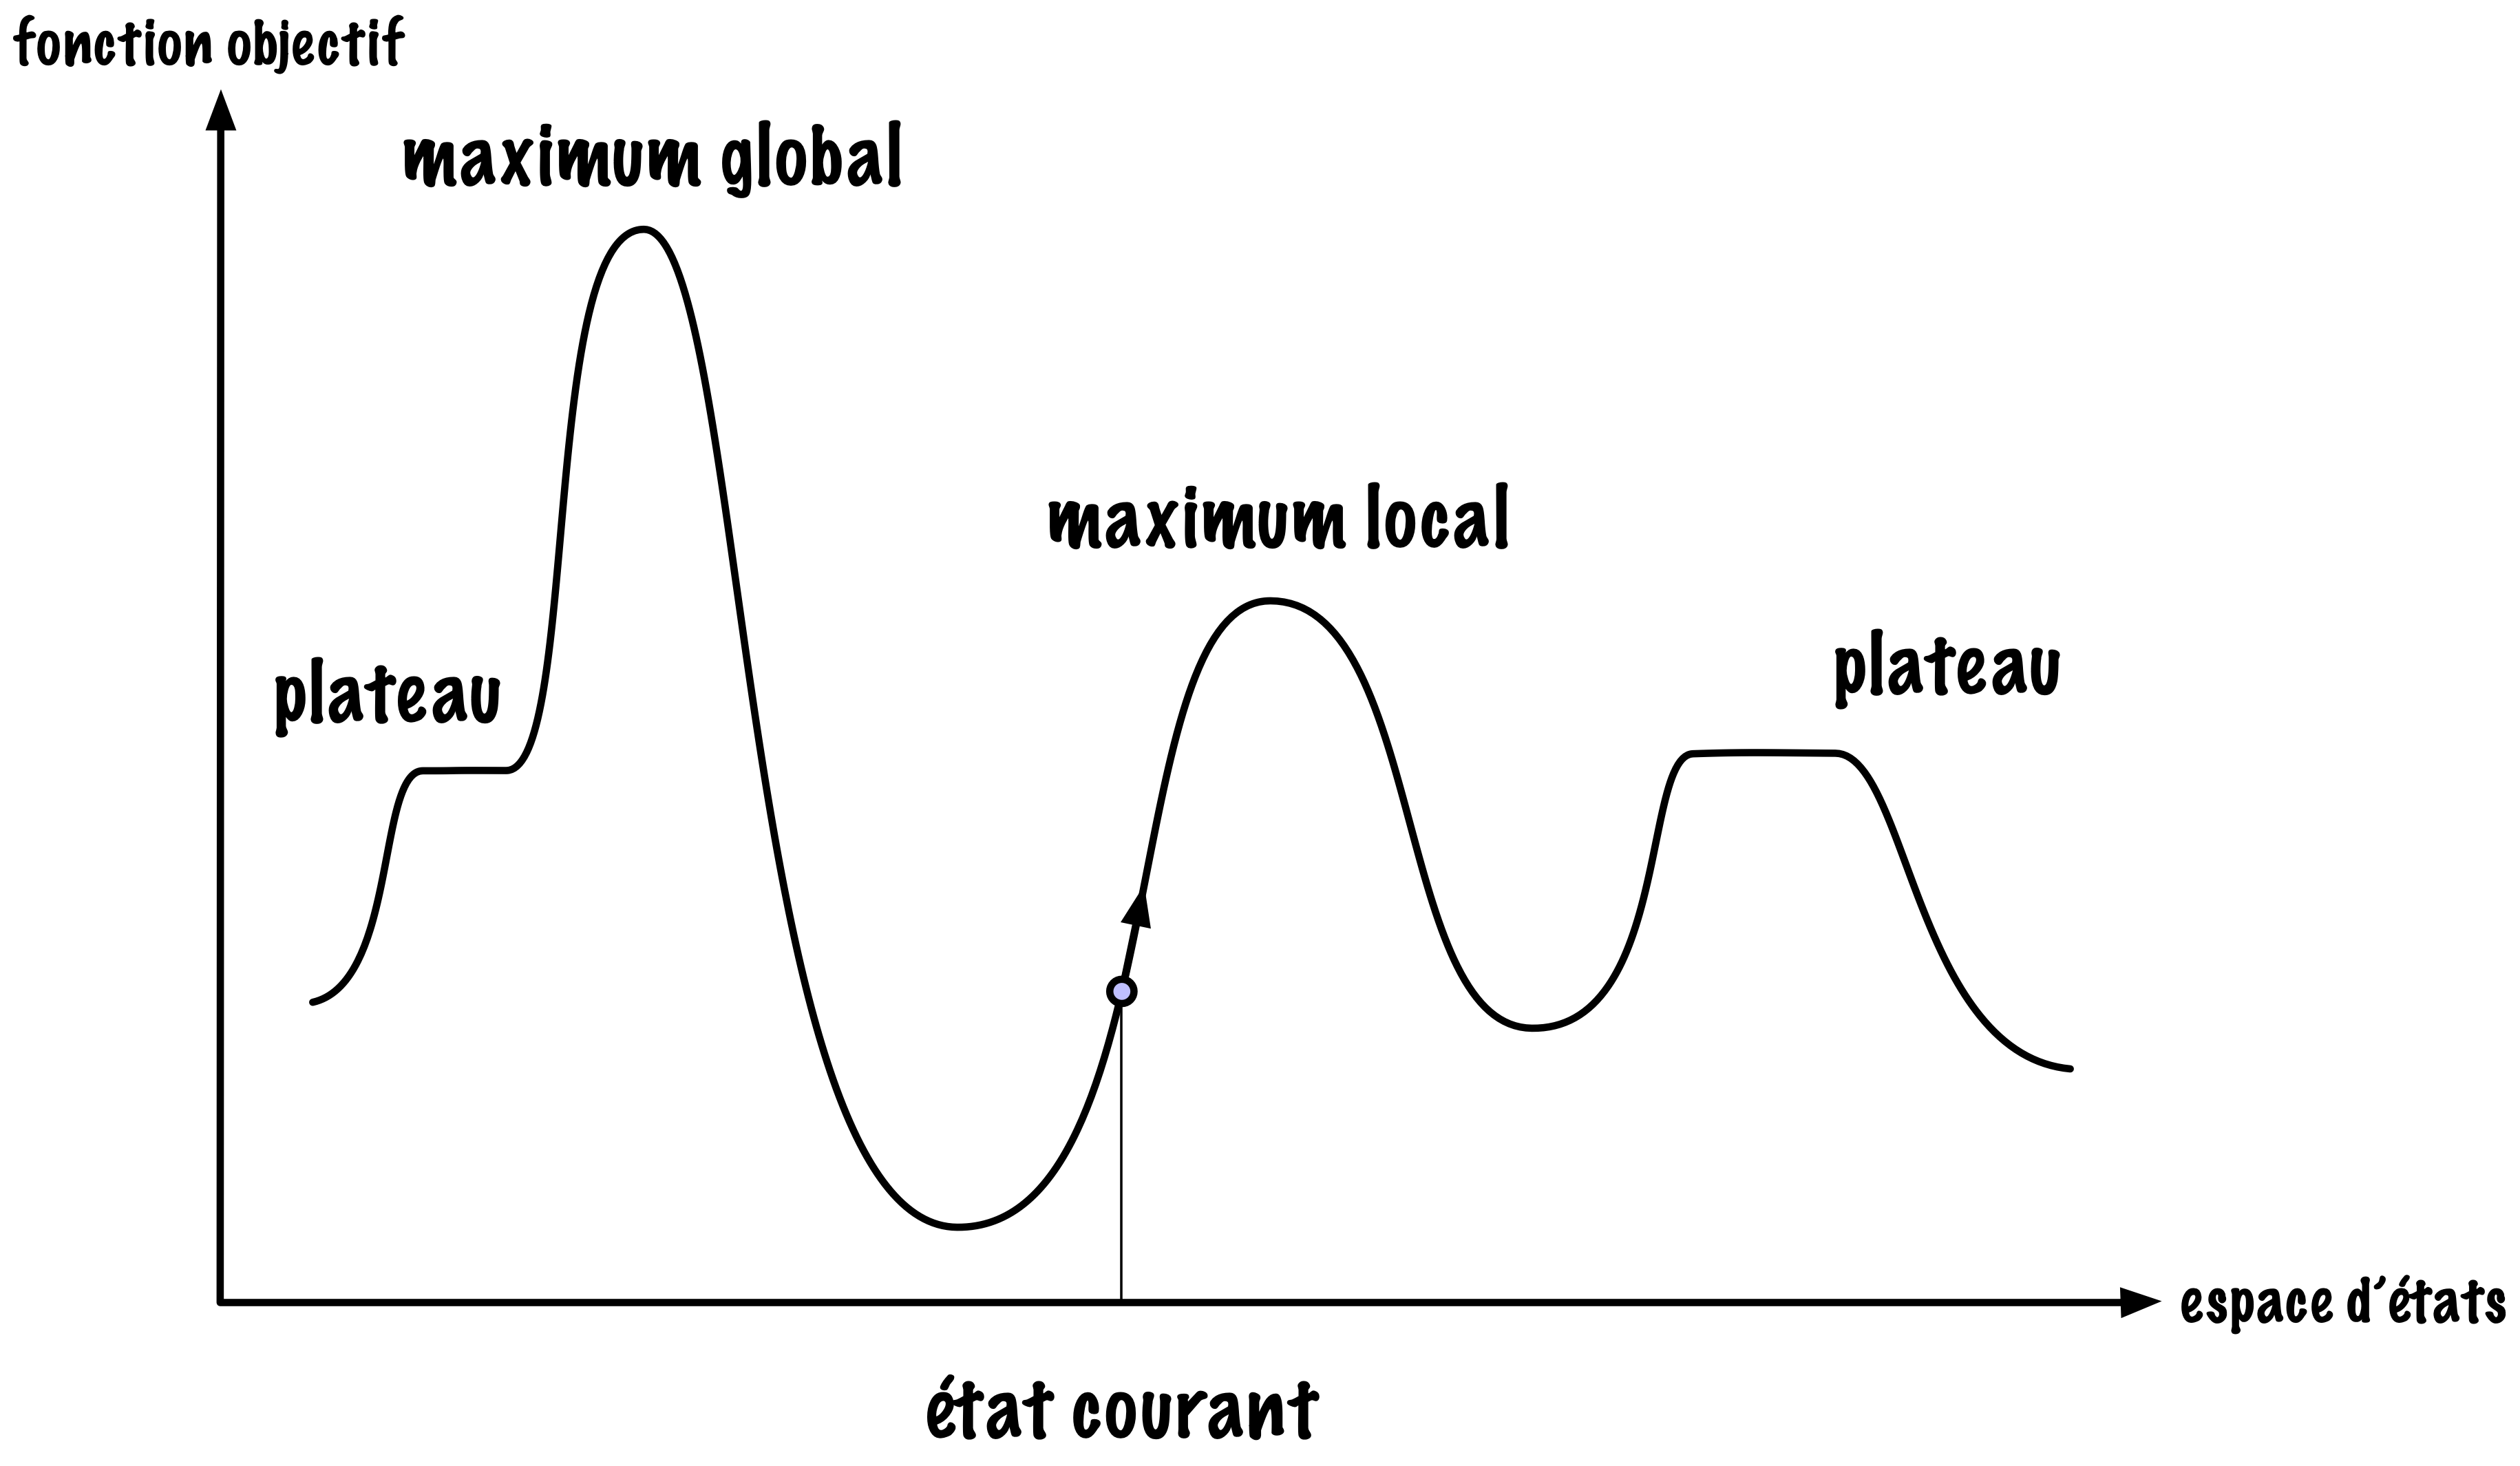

**Attribution**: adapté de Russell et Norvig (2020), page 111.

## *Hill Climbing*

Étant donné en entrée un *problème*

- *current* est l’*état initial* du *problème*

- **tant que** *non terminé* **faire**

  - *neighbour* est l’état successeur de plus grande valeur de *current*
  - si valeur(*neighbour*) $\le$ valeur(*current*) alors **retourner**
    *current*
  - assigner *neighbour* à *current*

La montée de colline ne garde pas la trace des états visités
précédemment et n’anticipe pas au-delà de ses voisins immédiats. Elle
conserve un état courant et se déplace dans la direction de l’ascension
la plus abrupte.

En inversant le signe de la fonction objectif, l’algorithme peut être
adapté pour rechercher un minimum local.

## 8-Reines

Comment représenteriez-vous l’**état courant**?

. . .

Pourquoi l’utilisation d’une grille pour représenter l’**état courant**
est-elle sous-optimale?

. . .

Une représentation en grille permet le **placement illégal de reines**
dans la même colonne.

. . .

À la place, nous pouvons représenter l’état comme une liste
($\mathrm{état}$), où chaque élément correspond à la position de la
ligne de la reine dans sa colonne respective.

En d’autres termes, $\mathrm{état}[i]$ est la ligne de la reine dans la
colonne $i$.

## Représentation de l’état

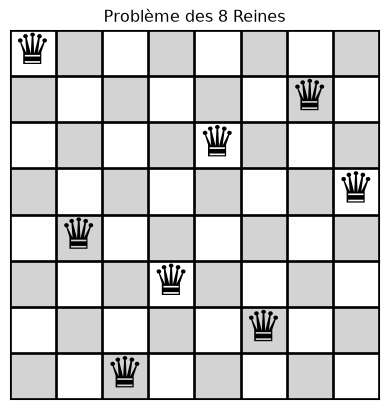

In [3]:
# Exemple de plateau pour le problème des 8-Reines
# Représente une solution valide pour les 8-Reines
board = [0, 4, 7, 5, 2, 6, 1, 3]  

display_n_queens(board, 5)

``` python
etat = [0, 4, 7, 5, 2, 6, 1, 3]
```

## `create_initial_state`

In [5]:
import random
random.seed(7)

def create_initial_state(n):

    """Génère un état initial aléatoire avec une reine par colonne."""

    return [random.randint(0, n - 1) for _ in range(n)]

Qu’en **pensez-vous** ?

## `create_initial_state`

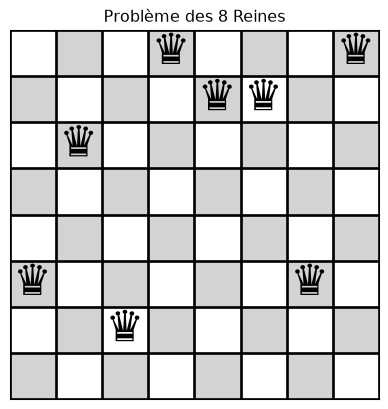

In [6]:
etat = create_initial_state(8)
display_n_queens(etat, 5)

In [7]:
etat 

[5, 2, 6, 0, 1, 1, 5, 0]

Permet deux Reines dans la même ligne? Comment cela peut-il être corrigé
?

## Représentation des 8-Reines

Échiquier $8 \times 8$.

- **Placement sans contrainte** : $\binom{64}{8} = 4,426,165,368$
  configurations possibles, représentant la sélection de 8 cases parmi
  64.

- **Contrainte de colonne** : Utilisez une liste de longueur 8, chaque
  entrée indiquant la ligne d’une reine dans sa colonne respective, ce
  qui donne $8^8 = 16,777,216$ configurations.

- **Contraintes de ligne et de colonne** : Modélisez les états du
  plateau comme des permutations des indices de ligne des 8 reines,
  réduisant les configurations à $8! = 40,320$.

Cela souligne l’importance de choisir une bonne représentation.

## `create_initial_state`

In [8]:
import random
random.seed(7)

def create_initial_state(n):

    """Génère une permutation des nombres de 0 à n-1 comme état initial."""

    etat = list(range(n))
    random.shuffle(etat)

    return etat

## `create_initial_state`

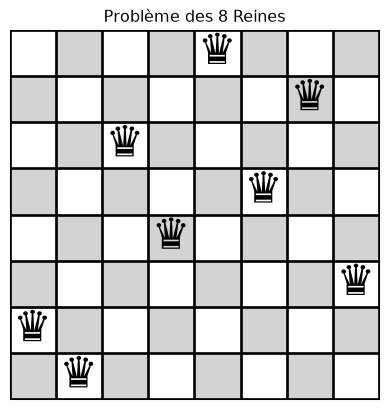

In [9]:
etat = create_initial_state(8)
display_n_queens(etat, 5)

In [10]:
etat 

[6, 7, 2, 4, 0, 3, 1, 5]

## `calculate_conflicts`

In [11]:
def calculate_conflicts(etat):

    n = len(etat)
    conflits = 0

    for col_i in range(n):
        for col_j in range(col_i + 1, n):
            row_i = etat[col_i]
            row_j = etat[col_j]
            if row_i == row_j:                 # même ligne
                conflits += 1
            if col_i - row_i == col_j - row_j: # même diagonale
                conflits += 1
            if col_i + row_i == col_j + row_j: # même antidiagonale
                conflits += 1

    return conflits

## `calculate_conflicts`

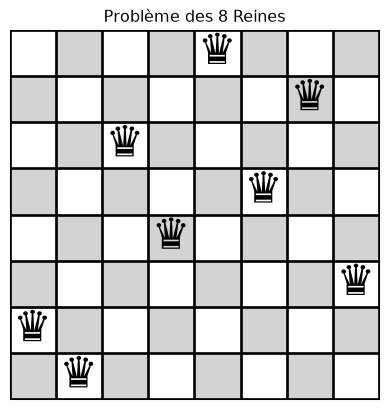

In [12]:
display_n_queens(etat, 5)

    5

## `get_neighbors_rn`

In [14]:
def get_neighbors_rn(etat):

    """Génère des états voisins en déplaçant une reine à la fois vers une nouvelle ligne."""

    voisins = []
    n = len(etat)

    for col in range(n):
        for row in range(n):
            if (etat[col] != row):
              nouvel_etat = etat[:]  # copie de l'état
              nouvel_etat[col] = row
              voisins.append(nouvel_etat)

    return voisins

Russell et Norvig (2020), $8 \times 7 = 56$ voisins

## `get_neighbors_rn`

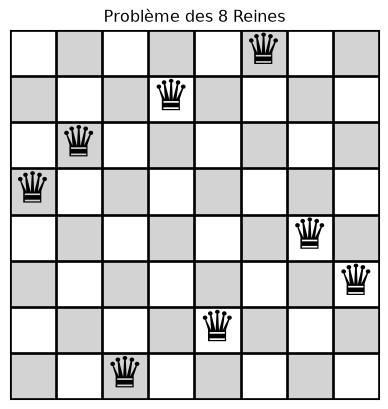

In [15]:
etat = create_initial_state(8)
display_n_queens(etat, 5)

## `get_neighbors_rn`

In [16]:
initial_state_8 = create_initial_state(8)
print(initial_state_8)
for s in get_neighbors_rn(initial_state_8):
  print(f"{s} -> # of conflicts = {calculate_conflicts(s)}")

[7, 4, 2, 5, 1, 0, 3, 6]
[0, 4, 2, 5, 1, 0, 3, 6] -> # of conflicts = 6
[1, 4, 2, 5, 1, 0, 3, 6] -> # of conflicts = 5
[2, 4, 2, 5, 1, 0, 3, 6] -> # of conflicts = 6
[3, 4, 2, 5, 1, 0, 3, 6] -> # of conflicts = 6
[4, 4, 2, 5, 1, 0, 3, 6] -> # of conflicts = 6
[5, 4, 2, 5, 1, 0, 3, 6] -> # of conflicts = 8
[6, 4, 2, 5, 1, 0, 3, 6] -> # of conflicts = 5
[7, 0, 2, 5, 1, 0, 3, 6] -> # of conflicts = 4
[7, 1, 2, 5, 1, 0, 3, 6] -> # of conflicts = 4
[7, 2, 2, 5, 1, 0, 3, 6] -> # of conflicts = 3
[7, 3, 2, 5, 1, 0, 3, 6] -> # of conflicts = 5
[7, 5, 2, 5, 1, 0, 3, 6] -> # of conflicts = 3
[7, 6, 2, 5, 1, 0, 3, 6] -> # of conflicts = 4
[7, 7, 2, 5, 1, 0, 3, 6] -> # of conflicts = 4
[7, 4, 0, 5, 1, 0, 3, 6] -> # of conflicts = 5
[7, 4, 1, 5, 1, 0, 3, 6] -> # of conflicts = 6
[7, 4, 3, 5, 1, 0, 3, 6] -> # of conflicts = 8
[7, 4, 4, 5, 1, 0, 3, 6] -> # of conflicts = 6
[7, 4, 5, 5, 1, 0, 3, 6] -> # of conflicts = 7
[7, 4, 6, 5, 1, 0, 3, 6] -> # of conflicts = 6
[7, 4, 7, 5, 1, 0, 3, 6] -> # of co

## `get_neighbors`

In [17]:
def get_neighbors(etat):
    """Génère des états voisins en échangeant deux lignes."""
    voisins = []
    n = len(etat)

    for i in range(n):
        for j in range(i + 1, n):
            nouvel_etat = etat[:]
            nouvel_etat[i], nouvel_etat[j] = nouvel_etat[j], nouvel_etat[i]
            voisins.append(nouvel_etat)

    return voisins

$\frac{8 \times 7}{2} = 28$ voisins

## `get_neighbors`

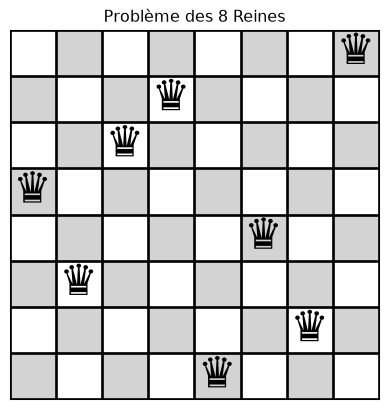

In [18]:
etat = create_initial_state(8)
display_n_queens(etat, 5)

## `get_neighbors`

In [19]:
print(initial_state_8)
for s in get_neighbors(initial_state_8):
  print(f"{s} -> # of conflicts = {calculate_conflicts(s)}")

[7, 4, 2, 5, 1, 0, 3, 6]
[4, 7, 2, 5, 1, 0, 3, 6] -> # of conflicts = 4
[2, 4, 7, 5, 1, 0, 3, 6] -> # of conflicts = 6
[5, 4, 2, 7, 1, 0, 3, 6] -> # of conflicts = 7
[1, 4, 2, 5, 7, 0, 3, 6] -> # of conflicts = 2
[0, 4, 2, 5, 1, 7, 3, 6] -> # of conflicts = 4
[3, 4, 2, 5, 1, 0, 7, 6] -> # of conflicts = 5
[6, 4, 2, 5, 1, 0, 3, 7] -> # of conflicts = 5
[7, 2, 4, 5, 1, 0, 3, 6] -> # of conflicts = 3
[7, 5, 2, 4, 1, 0, 3, 6] -> # of conflicts = 3
[7, 1, 2, 5, 4, 0, 3, 6] -> # of conflicts = 4
[7, 0, 2, 5, 1, 4, 3, 6] -> # of conflicts = 5
[7, 3, 2, 5, 1, 0, 4, 6] -> # of conflicts = 3
[7, 6, 2, 5, 1, 0, 3, 4] -> # of conflicts = 5
[7, 4, 5, 2, 1, 0, 3, 6] -> # of conflicts = 10
[7, 4, 1, 5, 2, 0, 3, 6] -> # of conflicts = 2
[7, 4, 0, 5, 1, 2, 3, 6] -> # of conflicts = 5
[7, 4, 3, 5, 1, 0, 2, 6] -> # of conflicts = 7
[7, 4, 6, 5, 1, 0, 3, 2] -> # of conflicts = 7
[7, 4, 2, 1, 5, 0, 3, 6] -> # of conflicts = 3
[7, 4, 2, 0, 1, 5, 3, 6] -> # of conflicts = 5
[7, 4, 2, 3, 1, 0, 5, 6] -> # of c

## `hill_climbing`

In [20]:
import numpy as np

def hill_climbing(etat_courant):

    conflits_courants = calculate_conflicts(etat_courant)

    while True:

        if conflits_courants == 0:
          return etat_courant

        voisins = get_neighbors(etat_courant)

        conflits = [calculate_conflicts(voisin) for voisin in voisins]

        if (min(conflits)) > conflits_courants:
          return None # Aucune amélioration trouvée, bloqué dans un minimum local

        arg_best = np.argmin(conflits)
        etat_courant = voisins[arg_best]
        conflits_courants = conflits[arg_best]

Le programme ci-haut présente un défi majeur. Quel est-il exactement ?

Il est important de noter que, dans ce contexte particulier, le problème
est défini de manière à ce que la solution recherchée soit exempte de
tout conflit. Cependant, dans certains problèmes d’optimisation, la
valeur minimale de la fonction objective n’est pas préalablement
déterminée.

Le principal problème est que l’algorithme risque d’entrer dans une
boucle infinie si la condition `min(conflits == conflits_courant)` est
satisfaite.

Deux scénarios peuvent se présenter : soit le plateau est suivi d’une
pente ascendante, soit il représente un maximum local. Dans le premier
cas, l’algorithme pourrait potentiellement sortir du plateau, bien que
cela ne soit pas garanti. Pour prévenir les boucles infinies, il serait
judicieux d’implémenter un mécanisme approprié.

## `hill_climbing` (version 2)

In [21]:
MAX_SIDE_MOVES = 100

def hill_climbing(etat_courant):

    conflits_courants = calculate_conflicts(etat_courant)
    mouvements_lateraux = 0

    while True:

        if conflits_courants == 0:
          return etat_courant

        voisins = get_neighbors(etat_courant)

        conflits = [calculate_conflicts(voisin) for voisin in voisins]

        if (min(conflits)) > conflits_courants:
          return None  # Aucune amélioration trouvée, bloqué dans un minimum local

        if (min(conflits)) == conflits_courants:
          mouvements_lateraux += 1  # Plateau

        if mouvements_lateraux > MAX_SIDE_MOVES:
          return None

        arg_best = np.argmin(conflits)
        etat_courant = voisins[arg_best]
        conflits_courants = conflits[arg_best]

## Résoudre

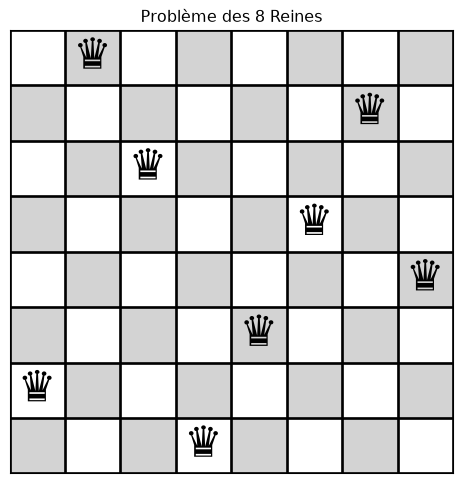

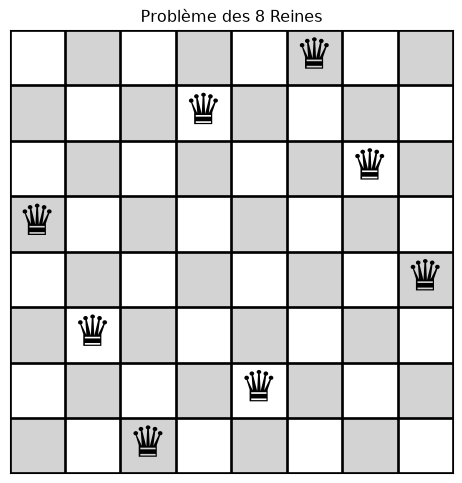

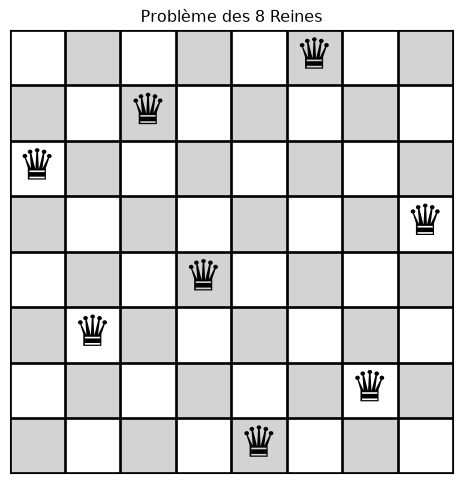

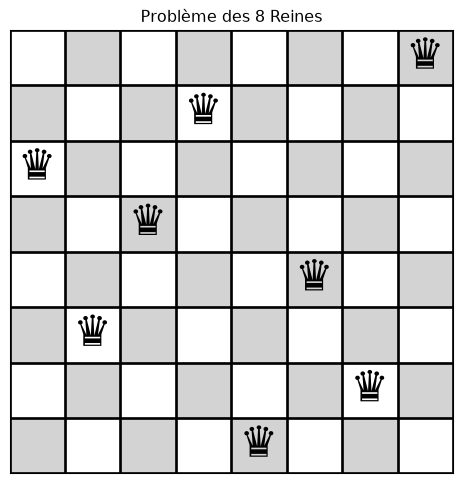

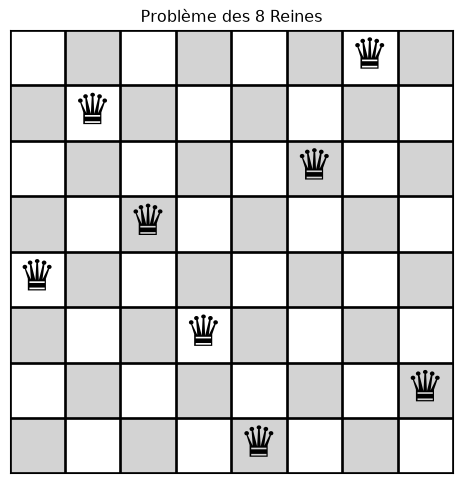

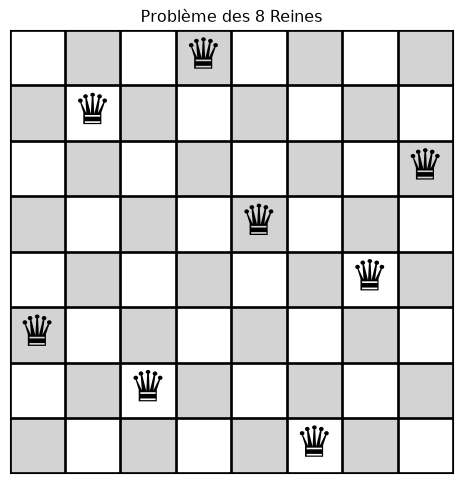

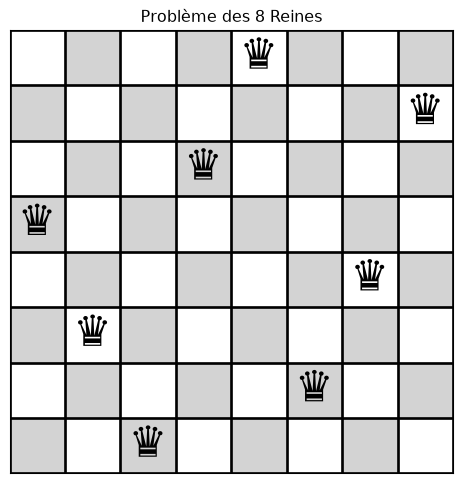

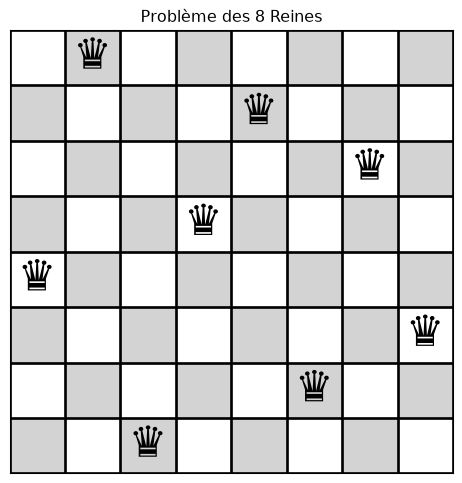

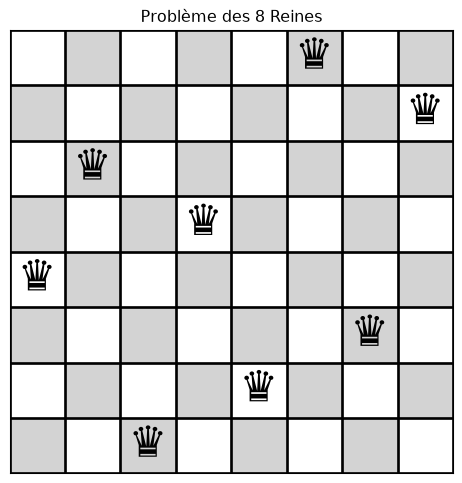

10 essais, nombre de solutions = 9, 0 déjà vues

In [22]:
random.seed(7)

solutions = 0
explored = set()
nb_explored = 0

for i in range(10):
  etat = create_initial_state(8)

  nouvel_etat = hill_climbing(etat)

  if (nouvel_etat != None):
    display_n_queens(nouvel_etat, 6)
    if tuple(nouvel_etat) in explored:
      nb_explored += 1
    else:
      explored.add(tuple(nouvel_etat))

    solutions += 1

print(f"10 essais, nombre de solutions = {solutions}, {nb_explored} déjà vues")

## Résoudre (2)

In [23]:
random.seed(7)

solutions = 0

explored = set()
nb_duplicates = 0

nb_runs = 10 if DRAFT else 1000

for i in range(nb_runs):

  state = create_initial_state(8)

  new_state = hill_climbing(state)

  if (new_state != None):

    if tuple(new_state) in explored:
      nb_duplicates += 1
    else:
      explored.add(tuple(new_state))

    solutions += 1

print(f"{nb_runs} essais, nombre de solutions = {solutions}, {len(explored)} uniques")

1000 essais, nombre de solutions = 704, 92 uniques

## Résoudre 40-Reines

$40! = 8.1591528325 \times 10^{47}$

. . .

10 essais, nombre de solutions = 6, 6 uniques

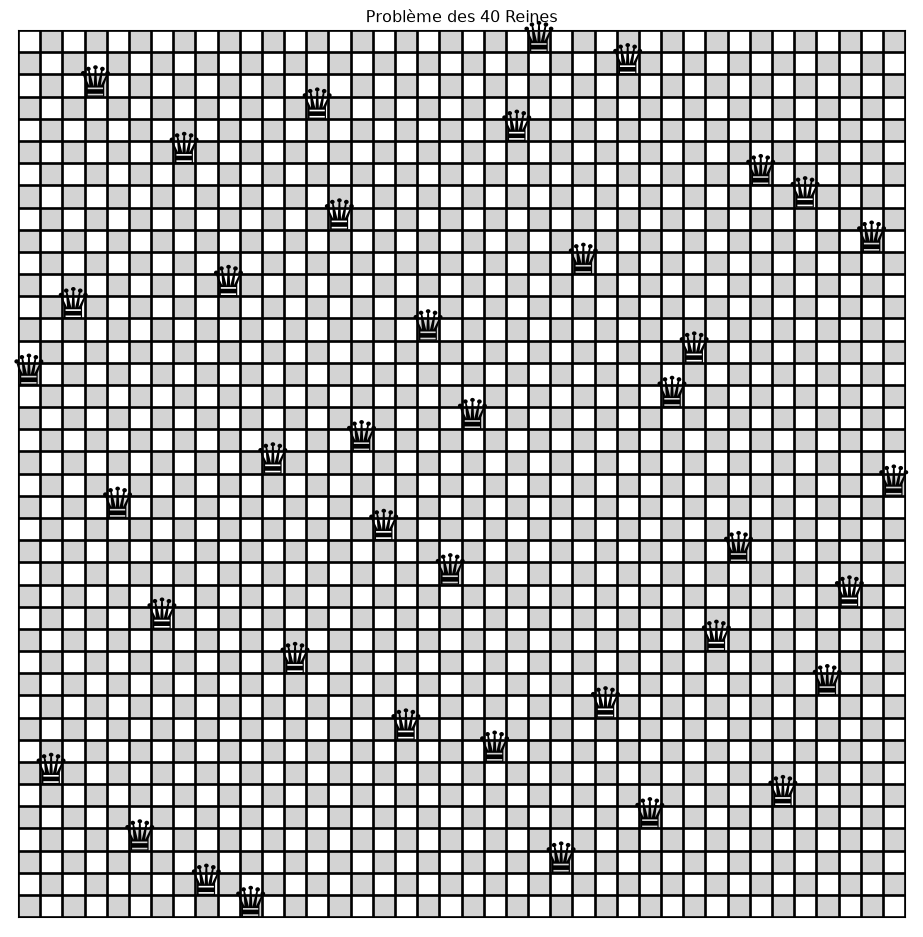

Temps écoulé : 14.6590 secondes

In [25]:
import time

start_time = time.time()  # Record the start time

random.seed(7)

solutions = 0

explored = set()
nb_duplicates = 0

nb_runs = 1 if DRAFT else 10

for i in range(nb_runs):

  state = create_initial_state(40)

  new_state = hill_climbing(state)

  if (new_state != None):

    if tuple(new_state) in explored:
      nb_duplicates += 1
    else:
      explored.add(tuple(new_state))

    solutions += 1

print(f"{nb_runs} essais, nombre de solutions = {solutions}, {len(explored)} uniques")

one_board = next(iter(explored))
display_n_queens(one_board, 12)

end_time = time.time()  # Record the end time
elapsed_time = end_time - start_time  # Calculate the elapsed time

print(f"Temps écoulé : {elapsed_time:.4f} secondes")

## Itérations et mouvement latéraux

In [26]:
MAX_SIDE_MOVES = 100

def hill_climbing_counts(etat_courant):

    """Algorithme de montée de colline pour résoudre le problème des N-Reines."""

    conflits_courants = calculate_conflicts(etat_courant)
    mouvements_lateraux = 0
    iterations = 0

    while True:

        if conflits_courants == 0:
          return (iterations, mouvements_lateraux, etat_courant)

        iterations += 1

        voisins = get_neighbors(etat_courant)

        conflits = [calculate_conflicts(voisin) for voisin in voisins]

        if (min(conflits)) > conflits_courants:
          print("here")
          return (iterations, 1, None)  # Aucune amélioration trouvée, bloqué dans un minimum local

        if (min(conflits)) == conflits_courants:
          mouvements_lateraux += 1  # Plateau

        if mouvements_lateraux > MAX_SIDE_MOVES:
          return (iterations, 2, None)

        arg_best = np.argmin(conflits)
        etat_courant = voisins[arg_best]
        conflits_courants = conflits[arg_best]

In [27]:
random.seed(7)

solutions = 0

explored = set()
nb_duplicates = 0

nb_runs = 10 if DRAFT else 1000

iterations = []
sides = []

iterations_none = []
sides_none = []

for i in range(nb_runs):

  state = create_initial_state(8)

  (i, s, new_state) = hill_climbing_counts(state)

  if new_state != None:
    iterations.append(i)
    sides.append(s)
  else:
    iterations_none.append(i)
    sides_none.append(s)

  if new_state != None:

    if tuple(new_state) in explored:
      nb_duplicates += 1
    else:
      explored.add(tuple(new_state))

    solutions += 1

print(f"{nb_runs} essais, nombre de solutions = {solutions}, {len(explored)} uniques")

1000 essais, nombre de solutions = 704, 92 uniques

## Itérations et mouvement latéraux

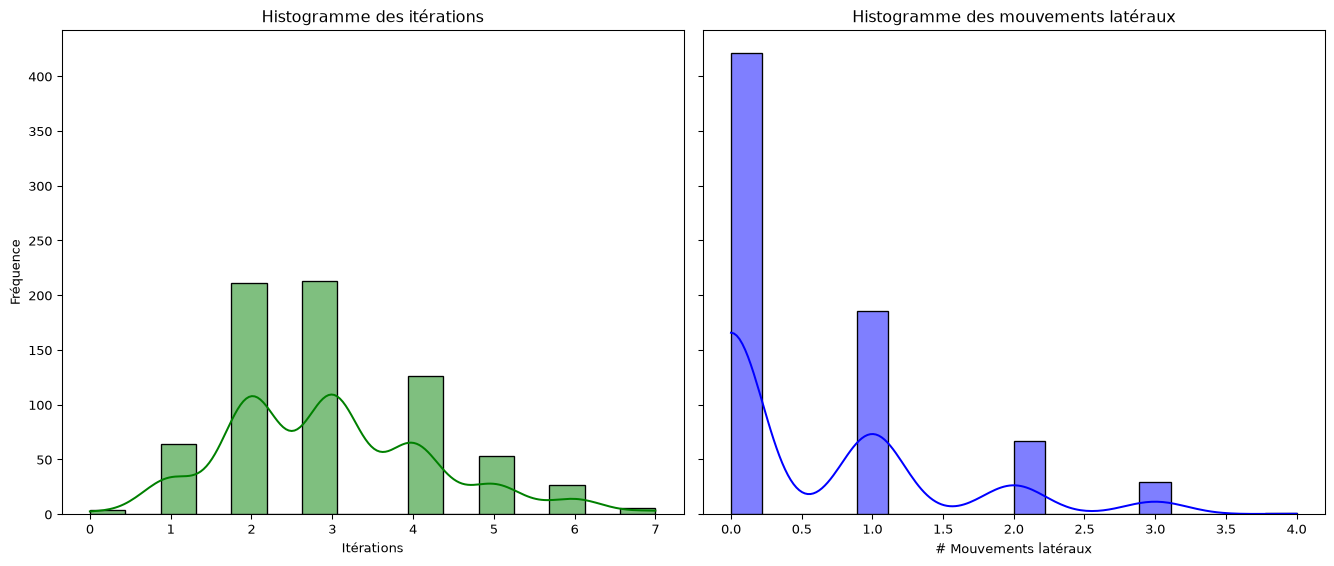

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

# Configurer la structure des sous-graphiques
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Tracer l'histogramme pour `iterations`
sns.histplot(iterations, kde=True, color='green', ax=axes[0], edgecolor='black')
axes[0].set_title("Histogramme des itérations")
axes[0].set_xlabel("Itérations")
axes[0].set_ylabel("Fréquence")

# Tracer l'histogramme pour `sides`
sns.histplot(sides, kde=True, color='blue', ax=axes[1], edgecolor='black')

axes[1].set_title("Histogramme des mouvements latéraux")
axes[1].set_xlabel("# Mouvements latéraux")

# Afficher le graphique
plt.tight_layout()
plt.show()

## 20-Reines

In [29]:
random.seed(7)

solutions = 0

explored = set()
nb_duplicates = 0

nb_runs = 10 if DRAFT else 1000

iterations = []
sides = []

iterations_none = []
sides_none = []

for i in range(nb_runs):

  state = create_initial_state(20)

  (i, s, new_state) = hill_climbing_counts(state)

  if new_state != None:
    iterations.append(i)
    sides.append(s)
  else:
    iterations_none.append(i)
    sides_none.append(s)

  if new_state != None:

    if tuple(new_state) in explored:
      nb_duplicates += 1
    else:
      explored.add(tuple(new_state))

    solutions += 1

print(f"{nb_runs} essais, nombre de solutions = {solutions}, {len(explored)} uniques")

1000 essais, nombre de solutions = 566, 566 uniques

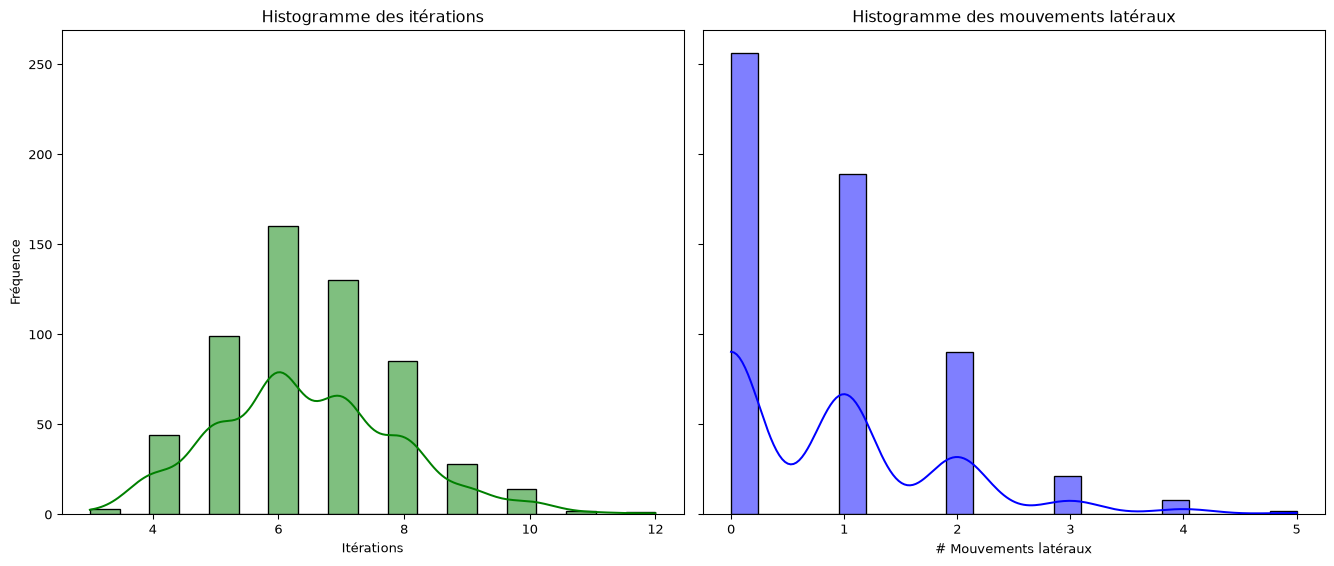

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

# Configurer la structure des sous-graphiques
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Tracer l'histogramme pour `iterations`
sns.histplot(iterations, kde=True, color='green', ax=axes[0], edgecolor='black')
axes[0].set_title("Histogramme des itérations")
axes[0].set_xlabel("Itérations")
axes[0].set_ylabel("Fréquence")

# Tracer l'histogramme pour `sides`
sns.histplot(sides, kde=True, color='blue', ax=axes[1], edgecolor='black')

axes[1].set_title("Histogramme des mouvements latéraux")
axes[1].set_xlabel("# Mouvements latéraux")

# Afficher le graphique
plt.tight_layout()
plt.show()

## Russell & Norvig

- La montée de colline **échoue 86 % du temps**.
  - Les tentatives réussies nécessitent en moyenne **4 étapes pour une
    solution**.
- Permettre **100 mouvements latéraux** augmente le taux de réussite de
  14 % à 94 %.
- L’espace de recherche contient $8^8 = 16,777,216$ états.
  - Implémentation de Russell & Norvig

Possède de nombreuses variantes, notamment la montée de colline avec
**redémarrage aléatoire**.

Dans l’implémentation que j’ai proposée, il ne semble pas y avoir de
minimums locaux. Toutefois, cela nécessite une vérification plus
approfondie.

## Échapper à un optimum local

Quels **mécanismes** permettraient à l’algorithme de **montée de
colline** d’échapper à un optimum local, qu’il s’agisse d’un minimum ou
d’un maximum local ?

Il doit accepter de descendre.

Une approche de marche aléatoire, qui ignore la valeur de la fonction
objectif, pourrait théoriquement trouver le maximum global. Cependant,
cette méthode est extrêmement inefficace.

## Remarque

Supposons que le problème d’optimisation soit une **minimisation**, où
l’objectif est de trouver une solution avec le **coût minimum**.

Descente de colline, descente de gradient.

# Recuit simulé

## Définition

Le **recuit simulé** (*simulated annealing*) est un algorithme
d’optimisation inspiré du processus de recuit en métallurgie. Il explore
l’espace de solutions de manière probabiliste en permettant des
**déplacements occasionnels vers le haut**, ce qui aide à **échapper aux
optima locaux**. L’algorithme **réduit progressivement la probabilité
d’accepter des solutions pires** en diminuant un paramètre de
“température”, convergeant ainsi vers une solution optimale ou
quasi-optimale.

## Recuit

> **Note**
>
> (Russell et Norvig 2020, 114)
>
> **En métallurgie**, le **recuit** est le processus de durcissement des
> métaux et du verre en les **chauffant à haute température** et en les
> **refroidissant progressivement**, permettant ainsi au matériau
> d’atteindre un **état cristallin à faible énergie**.

Le solide est chauffé jusqu’à son point de fusion, ce qui rend les
particules distribuées de manière aléatoire.

Ensuite, le matériau est refroidi progressivement, permettant aux
particules de se réorganiser en un état de faible énergie.

## Algorithme

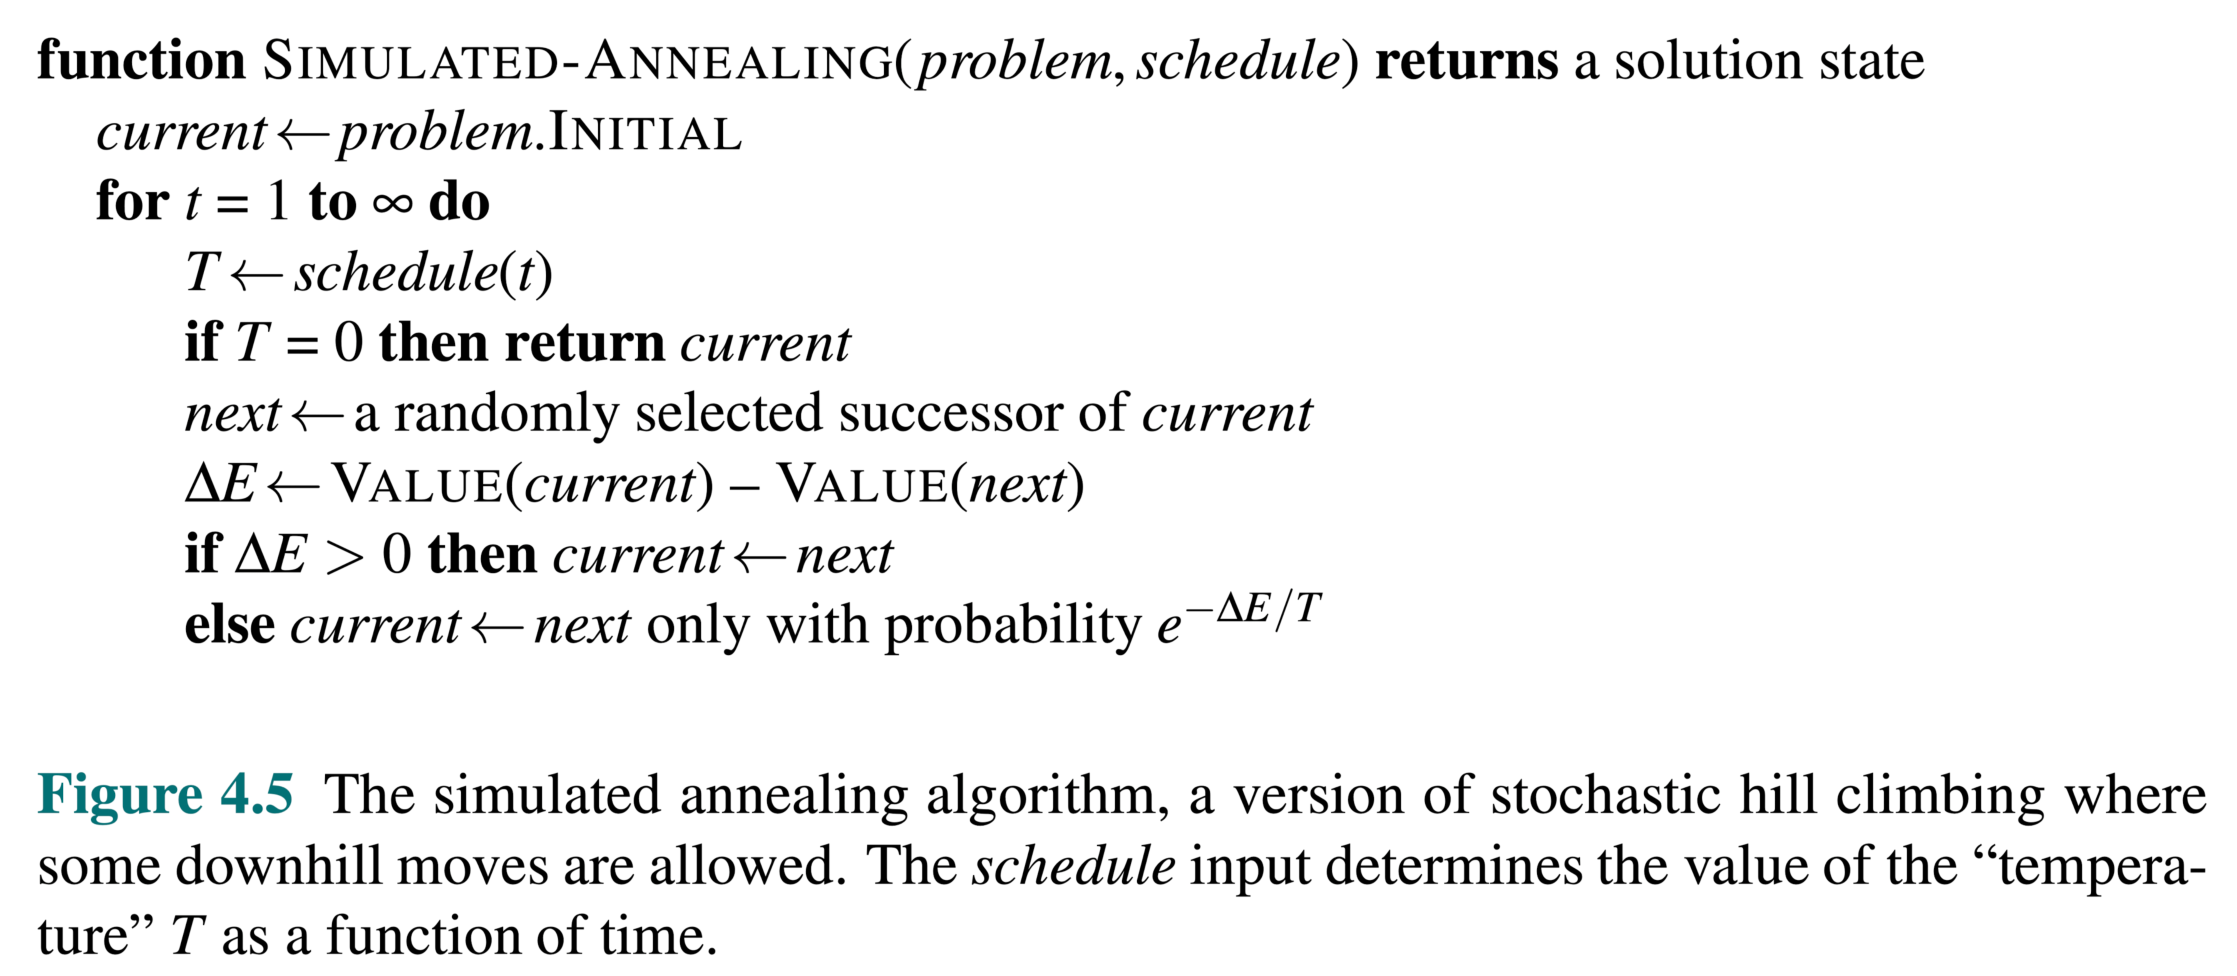

**Attribution** : (Russell et Norvig 2020, 115)

    1.  Cet algorithme ressemble à la montée de colline mais diffère en sélectionnant aléatoirement l’état suivant au lieu de choisir le meilleur mouvement.
    2.  Si le déplacement réduit la valeur de la fonction objectif, il est accepté sans condition.
    3.  Sinon, l’acceptation est probabiliste, en fonction de $\Delta E$ et $T$.

## Variation de $\Delta E$

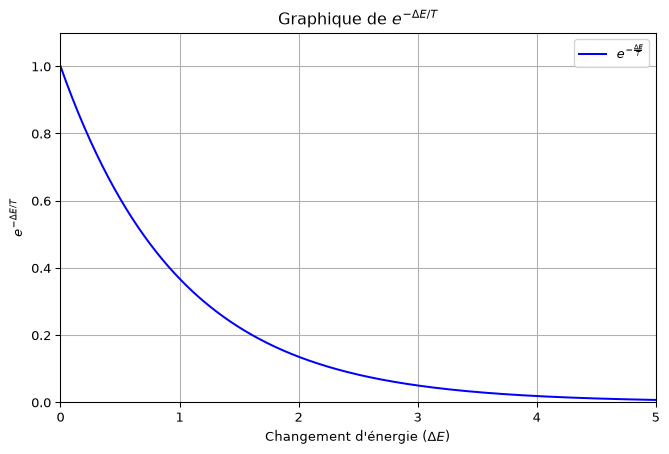

In [31]:
import numpy as np
import matplotlib.pyplot as plt

# Définir une température fixe, T
T = 1.0  # Vous pouvez ajuster cette valeur

# Définir une gamme de changements d'énergie, ΔE
delta_E = np.linspace(0, 5, 500)

# Calculer la fonction e^(-ΔE/T)
y = np.exp(-delta_E / T)

# Tracer la fonction
plt.figure(figsize=(8, 5))
plt.plot(delta_E, y, label=r'$e^{-\frac{\Delta E}{T}}$', color='blue')
plt.title(r"Graphique de $e^{-\Delta E / T}$")
plt.xlabel(r"Changement d'énergie ($\Delta E$)")
plt.ylabel(r'$e^{-\Delta E / T}$')
plt.ylim(0, 1.1)
plt.xlim(0, 5)
plt.grid(True)
plt.legend()
plt.show()

Les mouvements entraînant des **changements négatifs significatifs
(pires)** de la fonction objectif sont **moins susceptibles d’être
acceptés**.

## Variation de la température, $T$

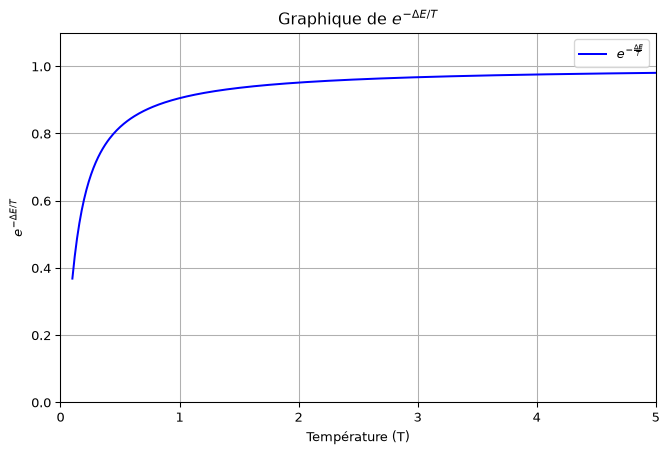

In [32]:
import numpy as np
import matplotlib.pyplot as plt

# Définir le changement d'énergie, ΔE
delta_E = 0.1  # Vous pouvez ajuster cette valeur

# Définir une gamme de températures, T
T = np.linspace(0.1, 5, 500)  # Éviter T=0 pour éviter la division par zéro

# Calculer la fonction e^(-ΔE/T)
y = np.exp(-delta_E / T)

# Tracer la fonction
plt.figure(figsize=(8, 5))
plt.plot(T, y, label=r'$e^{-\frac{\Delta E}{T}}$', color='blue')
plt.title(r'Graphique de $e^{-\Delta E / T}$')
plt.xlabel('Température (T)')
plt.ylabel(r'$e^{-\Delta E / T}$')
plt.ylim(0, 1.1)
plt.xlim(0, 5)
plt.grid(True)
plt.legend()
plt.show()

Pour un $\Delta E$ fixé (ici $0.1$), les changements sont plus
susceptibles d’être acceptés lorsque $T$ est élevé, au début de
l’algorithme.

## Variation de la température et de $\Delta E$

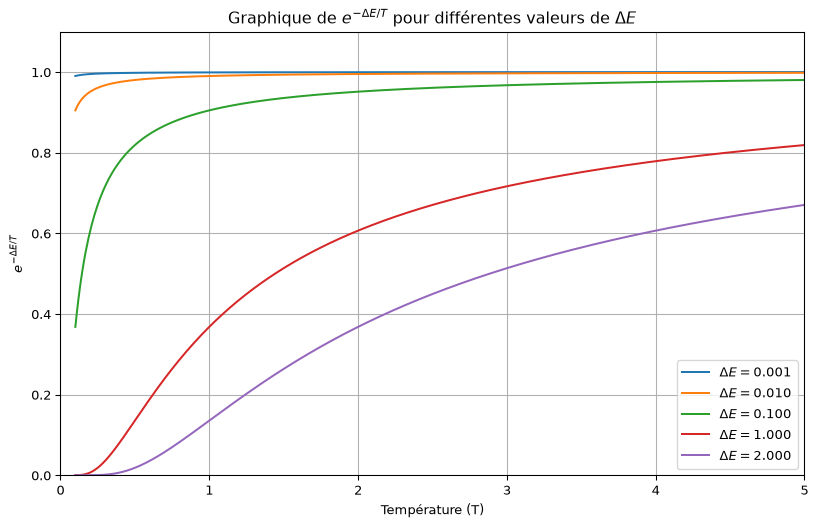

In [33]:
import numpy as np
import matplotlib.pyplot as plt

# Définir une gamme de températures, T
T = np.linspace(0.1, 5, 500)  # Éviter T=0 pour éviter la division par zéro

# Définir des valeurs spécifiques pour le changement d'énergie, ΔE
delta_E_values = [0.001, 0.01, 0.1, 1.0, 2.0]

# Tracer la fonction pour chaque ΔE
plt.figure(figsize=(10, 6))
for delta_E in delta_E_values:
    y = np.exp(-delta_E / T)
    plt.plot(T, y, label=r'$\Delta E = {:.3f}$'.format(delta_E))

# Personnaliser le graphique
plt.title(r'Graphique de $e^{-\Delta E / T}$ pour différentes valeurs de $\Delta E$')
plt.xlabel('Température (T)')
plt.ylabel(r'$e^{-\Delta E / T}$')
plt.ylim(0, 1.1)
plt.xlim(0, 5)
plt.grid(True)
plt.legend()
plt.show()

Les mauvais mouvements sont plus susceptibles d’être acceptés au début,
lorsque $T$ est élevé, et moins susceptibles de l’être lorsque $T$
diminue.

## Faire varier la température et $\Delta E$

In [ ]:
import { Inputs, Plot } from "@observablehq/plot"

viewof deltaE = Inputs.range([0.01, 100], {step: 0.01, value: 0.1, label: "ΔE", width: 300})

T_values = Array.from({length: 1000}, (_, i) => (i + 1) * 0.1)

function computeData(deltaE) {
  return T_values.map(T => ({
    T: T,
    value: Math.exp(-deltaE / T)
  }))
}

data = computeData(deltaE)

Plot.plot({
  marks: [
    Plot.line(data, {
      x: "T", 
      y: "value", 
      stroke: "steelblue", 
      strokeWidth: 2
    }),
    Plot.ruleX([0], {stroke: "black"}), // X-axis line
    Plot.ruleY([0], {stroke: "black"})  // Y-axis line
  ]
})

Graphique interactif à l’aide d’**[Observable
JS](https://observablehq.com/plot/)**.

## Théorie

> **Note**
>
> (Russell et Norvig 2020, 114)
>
> Si le calendrier abaisse $T$ à 0 suffisamment lentement, une propriété
> de la distribution de **Boltzmann** (alias **Gibbs**),
> $e^{\frac{\Delta E}{T}}$, est que toute la probabilité se concentre
> sur les maxima globaux, que l’algorithme trouvera avec une probabilité
> tendant vers 1.

**Voir aussi:** Laarhoven et Aarts (1987), Aarts et Korst (1989),
Gendreau et Potvin (2019)

## Définition

Le **problème du voyageur de commerce** (*travelling salesman problem*)
(TSP) est un problème d’optimisation classique qui cherche l’itinéraire
le plus court possible pour un voyageur devant visiter un ensemble de
villes, en revenant à la ville d’origine, tout en visitant chaque ville
exactement une fois.

Le défi est de déterminer le chemin le plus efficace, surtout lorsque le
nombre de villes augmente, en raison de l’explosion combinatoire des
itinéraires possibles.

## Voyageur de commerce

In [34]:
# On s'assure de toujours générer les mêmes coordonnées

np.random.seed(42)

# Générer des coordonnées aléatoires pour les villes

num_cities = 20
coordinates = np.random.rand(num_cities, 2) * 100

# Calculer la matrice des distances

distance_matrix = np.sqrt(((coordinates[:, np.newaxis] - coordinates[np.newaxis, :]) ** 2).sum(axis=2))

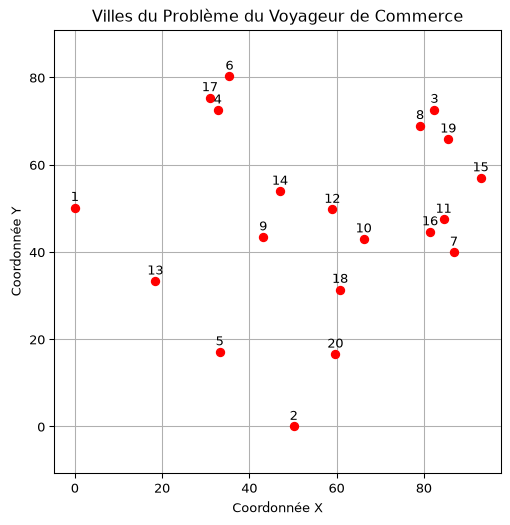

In [35]:
import matplotlib.pyplot as plt

def plot_cities(coordinates, title="Villes du Problème du Voyageur de Commerce"):

    """
    Trace les coordonnées données représentant les villes.
    
    Paramètres :
    - coordinates : Un tableau 2D NumPy de forme (n, 2) représentant les coordonnées (x, y).
    - title : Titre du graphique.
    """

    # Extraire les coordonnées x et y
    x = coordinates[:, 0]
    y = coordinates[:, 1]

    plt.figure(figsize=(6, 6))

    # Tracer les villes sous forme de points rouges
    plt.scatter(x, y, c='red', zorder=2)

    # Annoter les villes avec leurs indices
    for i, (xi, yi) in enumerate(zip(x, y)):
        plt.annotate(str(i + 1), (xi, yi), textcoords="offset points", xytext=(0, 5), ha='center')

    # Définir le titre et les étiquettes
    plt.title(title)
    plt.xlabel('Coordonnée X')
    plt.ylabel('Coordonnée Y')
    plt.grid(True)
    plt.axis('equal')  # Échelle égale pour les axes x et y
    plt.show()

plot_cities(distance_matrix)

## Comment représenter une solution?

. . .

Nous utiliserons une **liste** dans laquelle chaque élément représente
l’indice d’une ville, et l’ordre des éléments indique la **séquence de
visite des villes**.

## Solution aléatoire

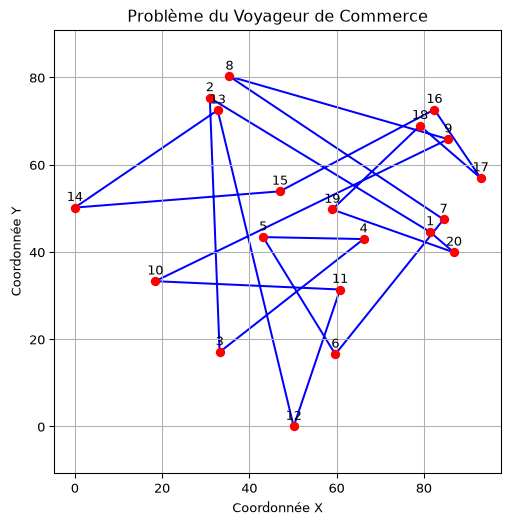

In [36]:
def plot_tsp_path(coordinates, path=None, title="Problème du Voyageur de Commerce"):

    """
    Trace les coordonnées données et éventuellement un chemin pour le TSP.
    
    Paramètres :
    - coordinates : Un tableau 2D NumPy de forme (n, 2) représentant les coordonnées (x, y).
    - path : Une liste ou un tableau d'indices représentant l'ordre des villes à visiter. Si None, les nœuds sont connectés dans l'ordre d'entrée.
    - title : Titre du graphique.
    """

    # Extraire les coordonnées x et y
    x = coordinates[:, 0]
    y = coordinates[:, 1]

    plt.figure(figsize=(6, 6))

    # Si un chemin est donné, réorganiser les coordonnées
    if path is not None:
        x = x[path]
        y = y[path]
    
    # Tracer les nœuds
    plt.scatter(x, y, c='red', zorder=2)

    # Annoter les nœuds avec leurs indices
    for i, (xi, yi) in enumerate(zip(x, y)):
        plt.annotate(str(i + 1), (xi, yi), textcoords="offset points", xytext=(0, 5), ha='center')

    # Tracer le chemin
    plt.plot(x, y, 'b-', zorder=1)

    # Si un chemin est fourni, connecter le dernier point au premier pour compléter le tour
    if path is not None:
        plt.plot([x[-1], x[0]], [y[-1], y[0]], 'b-', zorder=1)

    # Définir le titre et les étiquettes
    plt.title(title)
    plt.xlabel('Coordonnée X')
    plt.ylabel('Coordonnée Y')
    plt.grid(True)
    plt.axis('equal')  # Échelle égale pour les axes x et y
    plt.show()

num_cities = len(distance_matrix)
current_route = np.arange(num_cities)
np.random.shuffle(current_route)
plot_tsp_path(distance_matrix,current_route)

## Calcul de la distance totale

In [37]:
# Fonction pour calculer la distance totale d'un itinéraire donné

def calculate_total_distance(route, distance_matrix):

    total_distance = 0

    for i in range(len(route) - 1):
        total_distance += distance_matrix[route[i], route[i + 1]]

    total_distance += distance_matrix[route[-1], route[0]]  # Retourner au point de départ

    return total_distance

## Voisinage

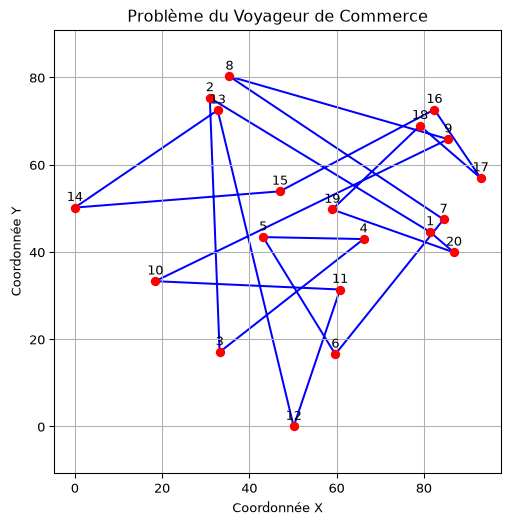

In [38]:
plot_tsp_path(distance_matrix,current_route)

Comment générer une solution voisine?

## Voisinage

Comment générer une solution voisine?

## Échanger deux villes

- **Description** : Sélectionner deux villes au hasard et échanger leurs
  positions.

- **Avantages** : Simple et efficace pour explorer des solutions
  voisines.

- **Inconvénients** : Le changement peut être trop minime, ce qui peut
  ralentir la convergence.

## Inverser le segment

- **Description** : Sélectionner deux indices et inverser le segment
  entre eux.

- **Avantages** : Plus efficace pour trouver des chemins plus courts par
  rapport aux échanges simples.

- **Inconvénients** : Peut être coûteux en calcul à mesure que le nombre
  de villes augmente.

## Supprimer & reconnecter

- **Description** : Supprime trois arêtes de l’itinéraire et reconnecte
  les segments de la meilleure façon possible. Cela peut générer jusqu’à
  7 itinéraires différents.

- **Avantages** : Apporte des changements plus importants et peut
  échapper aux optima locaux plus efficacement.

- **Inconvénients** : Plus complexe et coûteux en calcul à mettre en
  œuvre.

## Mouvement d’insertion

- **Description** : Sélectionner une ville et la déplacer à une position
  différente dans l’itinéraire.

- **Avantages** : Offre un équilibre entre petits et grands changements,
  utile pour affiner les solutions.

- **Inconvénients** : Peut nécessiter plus d’itérations pour converger
  vers une solution optimale.

## Mélanger le sous-ensemble

- **Description** : Sélectionner un sous-ensemble de villes dans
  l’itinéraire et mélanger leur ordre de manière aléatoire.

- **Avantages** : Introduit des changements plus importants et peut
  aider à échapper aux minima locaux.

- **Inconvénients** : Peut conduire à des itinéraires moins efficaces si
  mal géré.

## Générer une solution voisine aléatoire

In [39]:
# Fonction pour générer une solution voisine aléatoire

def get_neighbor(route):

    a, b = np.random.randint(0, len(route), size=2)
    if a > b:
        a, b = b, a

    new_route = route.copy()
    new_route[a:b+1] = new_route[a:b+1][::-1]  # Inverser le segment entre a et b

    return new_route

## Recuit simulé

In [40]:
def simulated_annealing(distance_matrix, initial_temp, cooling_rate, max_iterations):

    num_cities = len(distance_matrix)
    current_route = np.arange(num_cities)
    np.random.shuffle(current_route)

    current_cost = calculate_total_distance(current_route, distance_matrix)
    
    best_route = current_route.copy()
    best_cost = current_cost

    temperature = initial_temp

    for iteration in range(max_iterations):

        neighbor_route = get_neighbor(current_route)
        neighbor_cost = calculate_total_distance(neighbor_route, distance_matrix)
        
        # Accepter le voisin s'il est meilleur, ou avec une probabilité s'il est pire.

        delta_E = neighbor_cost - current_cost

        if neighbor_cost < current_cost or np.random.rand() < np.exp(-(delta_E)/temperature):
            current_route = neighbor_route
            current_cost = neighbor_cost

            if current_cost < best_cost:
                best_route = current_route.copy()
                best_cost = current_cost

        # Refroidir la température
        temperature *= cooling_rate

    return best_route, best_cost, temperatures, costs

## Remarques

- Lorsque $t \to \infty$, l’algorithme présente un comportement
  caractéristique d’une **marche aléatoire** (*random walk*). Pendant
  cette phase, tout état voisin, qu’il améliore ou non la fonction
  objectif, est accepté. Cela facilite l’exploration et se produit au
  début de l’exécution de l’algorithme.

## Remarques

- À l’inverse, lorsque $t \to 0$, l’algorithme se comporte comme une
  **montée de colline** (*hill climbing*). Dans cette phase, seuls les
  états qui améliorent la valeur de la fonction objectif sont acceptés,
  garantissant que l’algorithme se dirige systématiquement vers des
  solutions optimales — spécifiquement, vers des valeurs plus basses
  dans les problèmes de minimisation. Cette phase met l’accent sur
  l’exploitation des solutions prometteuses et se produit vers la fin de
  l’algorithme.

**Voir aussi** : [Properties of Simulated Annealing - Georgia Tech -
Machine Learning](https://youtu.be/enNgiWuIHAo). Vidéo Udacity (4m 10s).
Publiée le 2015-02-23.

1.  **Exploration** :

- L’exploration implique de rechercher dans une large zone de l’espace
  de recherche pour découvrir de nouvelles possibilités, solutions ou
  informations. L’objectif de l’exploration est de rassembler un
  ensemble diversifié de points de données ou de solutions qui
  pourraient potentiellement conduire à la découverte de meilleurs
  optima globaux. Elle empêche le processus de recherche de se bloquer
  dans des optima locaux en encourageant la considération de régions
  moins visitées ou inexplorées de l’espace de recherche.

- Dans les algorithmes, l’exploration peut être mise en œuvre en
  introduisant de la randomisation, en essayant de nouveaux chemins ou
  des chemins moins prometteurs, ou en utilisant des stratégies comme le
  recuit simulé ou les algorithmes génétiques qui encouragent la
  diversité.

1.  **Exploitation** :

- L’exploitation se concentre sur l’utilisation des informations connues
  pour affiner et améliorer les solutions existantes. Elle implique de
  concentrer l’effort de recherche autour des zones censées contenir des
  solutions de haute qualité basées sur des connaissances ou expériences
  antérieures. L’objectif est d’optimiser et de peaufiner ces solutions
  pour obtenir le meilleur résultat possible dans ces régions.

- Dans les algorithmes, l’exploitation peut être observée dans des
  stratégies telles que la montée de colline, la montée/descente de
  gradient ou les algorithmes gloutons, où la recherche est axée sur
  l’amélioration locale et la réalisation de gains incrémentaux.

## Exemple

In [41]:
# On s'assure de toujours générer les mêmes coordonnées
np.random.seed(42)

# Générer des coordonnées aléatoires pour les villes
num_cities = 20
coordinates = np.random.rand(num_cities, 2) * 100

# Calculer la matrice des distances
distance_matrix = np.sqrt(((coordinates[:, np.newaxis] - coordinates[np.newaxis, :]) ** 2).sum(axis=2))

# Paramètres du recuit simulé

initial_temp = 15
cooling_rate = 0.995
max_iterations = 1000

## Algorithme de Held–Karp

- **Introduction** : 1962 par Held, Karp et indépendamment par Bellman.
- **Problème** : Résout le problème du voyageur de commerce (TSP) avec
  la **programmation dynamique**.
- **Complexité temporelle** : $\Theta(2^n n^2)$.
- **Complexité spatiale** : $\Theta(2^n n)$.
- **Efficacité** : Meilleur que la méthode exhaustive $\Theta(n!)$, mais
  reste exponentiel.

## Algorithme de Held–Karp

In [42]:
from itertools import combinations
import numpy as np

def held_karp(distance_matrix):
    # Number of cities
    n = len(distance_matrix)

    # DP table: dp[subset][last_visited] = minimum cost to reach `last_visited` with `subset` of cities visited
    dp = {}

    # Initialize the DP table with the distances from the starting point (city 0)
    for i in range(1, n):
        dp[(1 << i, i)] = distance_matrix[0][i]

    # Iterate over all subset sizes
    for subset_size in range(2, n):
        for subset in combinations(range(1, n), subset_size):
            # Bitmask of the subset, excluding the starting city
            subset_mask = sum(1 << i for i in subset)
            for last in subset:
                # Update the DP table with the minimum cost for this subset and last city
                prev_subset_mask = subset_mask & ~(1 << last)
                dp[(subset_mask, last)] = min(
                    dp[(prev_subset_mask, k)] + distance_matrix[k][last]
                    for k in subset if k != last
                )

    # Find the minimum cost to complete the tour back to the starting point (city 0)
    full_mask = (1 << n) - 2  # All cities visited except starting city
    return min(dp[(full_mask, last)] + distance_matrix[last][0] for last in range(1, n))

# Example usage with a sample distance matrix
# distance_matrix = [
#     [0, 10, 15, 20],
#     [10, 0, 35, 25],
#     [15, 35, 0, 30],
#     [20, 25, 30, 0]
# ]
min_cost = held_karp(distance_matrix)
print(f"Held–Karp pour trouver le coût minimum: {min_cost:.2f}")

Held–Karp pour trouver le coût minimum: 386.43

Held et Karp (1962) and Bellman (1962)

## Trace d’exécution

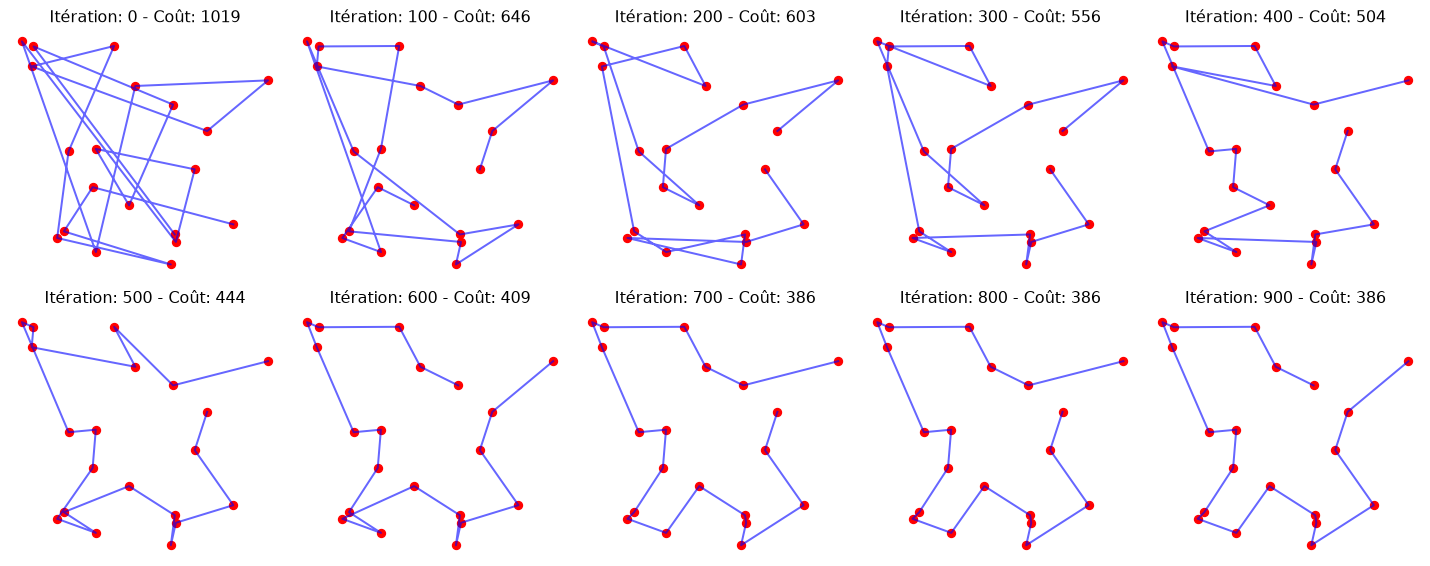

In [43]:
import numpy as np
import matplotlib.pyplot as plt

# Simulated Annealing function
def simulated_annealing(distance_matrix, initial_temp, cooling_rate, max_iterations):
    num_cities = len(distance_matrix)
    current_route = np.arange(num_cities)
    np.random.shuffle(current_route)
    current_cost = calculate_total_distance(current_route, distance_matrix)
    
    best_route = current_route.copy()
    best_cost = current_cost

    temperatures = []
    costs = []

    temperature = initial_temp

    # Collect intermediate solutions
    intermediate_solutions = []
    for iteration in range(max_iterations):
        neighbor_route = get_neighbor(current_route)
        neighbor_cost = calculate_total_distance(neighbor_route, distance_matrix)
        
        # Accept neighbor if it's better, or with a probability if it's worse
        if neighbor_cost < current_cost or np.random.rand() < np.exp(-(neighbor_cost - current_cost) / temperature):
            current_route = neighbor_route
            current_cost = neighbor_cost

            if current_cost < best_cost:
                best_route = current_route.copy()
                best_cost = current_cost

        # Store temperature and cost for plotting
        temperatures.append(temperature)
        costs.append(current_cost)

        # Cool down the temperature
        temperature *= cooling_rate

        # Collect intermediate solutions at regular intervals
        if iteration % (max_iterations // 10) == 0:
            intermediate_solutions.append((current_route.copy(), current_cost))

    # Plot 20 intermediate solutions in a 4x5 grid
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    axes = axes.flatten()
    for idx, (route, cost) in enumerate(intermediate_solutions):
        ax = axes[idx]
        ax.scatter(*zip(*coordinates), c='red', marker='o')
        ax.plot(*zip(*coordinates[route]), 'b-', alpha=0.6)
        ax.set_title(f"Itération: {idx*100} - Coût: {cost:.0f}")
        ax.axis('off')  # Turn off the axes for a cleaner look
    plt.tight_layout()
    plt.show()

    return best_route, best_cost, temperatures, costs

best_route, best_cost, temperatures, costs = simulated_annealing(distance_matrix, initial_temp, cooling_rate, max_iterations)

Lorsque j’ai initialement publié ces diapositives, la température
initiale sélectionnée de 1000 était excessivement élevée par rapport au
coût de la fonction objectif. En ajustant la température initiale à 15,
nous obtenons un équilibre plus efficace entre exploration et
exploitation.

En raison des instantanés pris toutes les 100 itérations, les
augmentations de coût ne sont pas visibles. Cela est illustré sur la
diapositive “Température et Coût”.

## Meilleur itinéraire

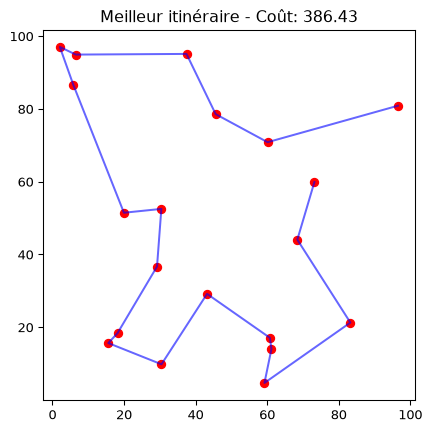

In [44]:
# Plot the final best route
plt.figure(figsize=(5, 5))
plt.scatter(*zip(*coordinates), c='red', marker='o')
plt.plot(*zip(*coordinates[best_route]), 'b-', alpha=0.6)
plt.title(f"Meilleur itinéraire - Coût: {best_cost:.2f}")
plt.show()

Nous avons identifié une **solution optimale**!

## Température et coût

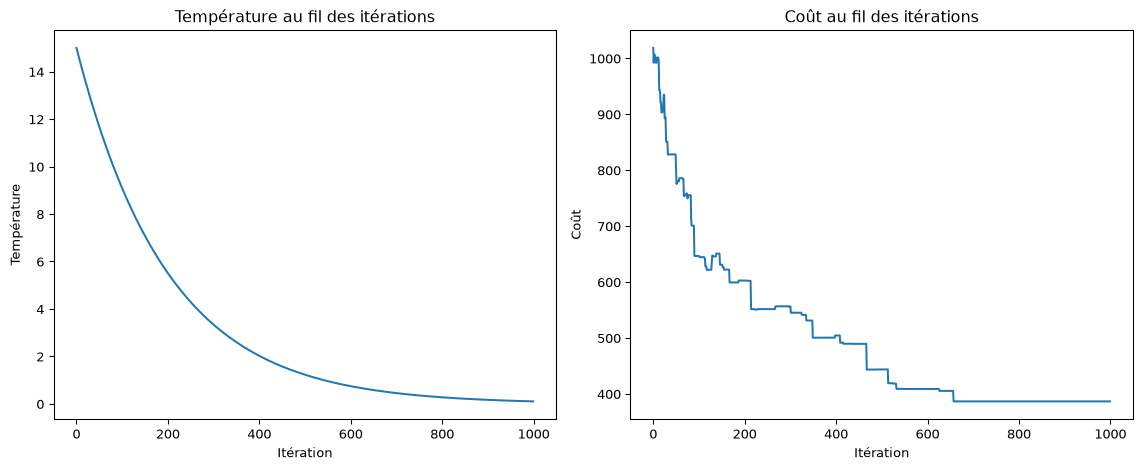

In [45]:
# Plot temperature and cost graphs
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(temperatures)
plt.title("Température au fil des itérations")
plt.xlabel("Itération")
plt.ylabel("Température")
plt.subplot(1, 2, 2)

plt.plot(costs)
plt.title("Coût au fil des itérations")

plt.xlabel("Itération")
plt.ylabel("Coût")

plt.tight_layout()
plt.show()

## Échange de voisins

- **Description** : Sélectionner deux villes au hasard et échanger leurs
  positions.

- **Avantages** : Simple et efficace pour explorer des solutions
  voisines.

- **Inconvénients** : Le changement peut être trop minime, ce qui peut
  ralentir la convergence.

In [46]:
def get_neighbor_swap(route):
    a, b = np.random.randint(0, len(route), size=2)
    new_route = route.copy()
    new_route[a], new_route[b] = new_route[b], new_route[a]
    return new_route

## Trace d’exécution

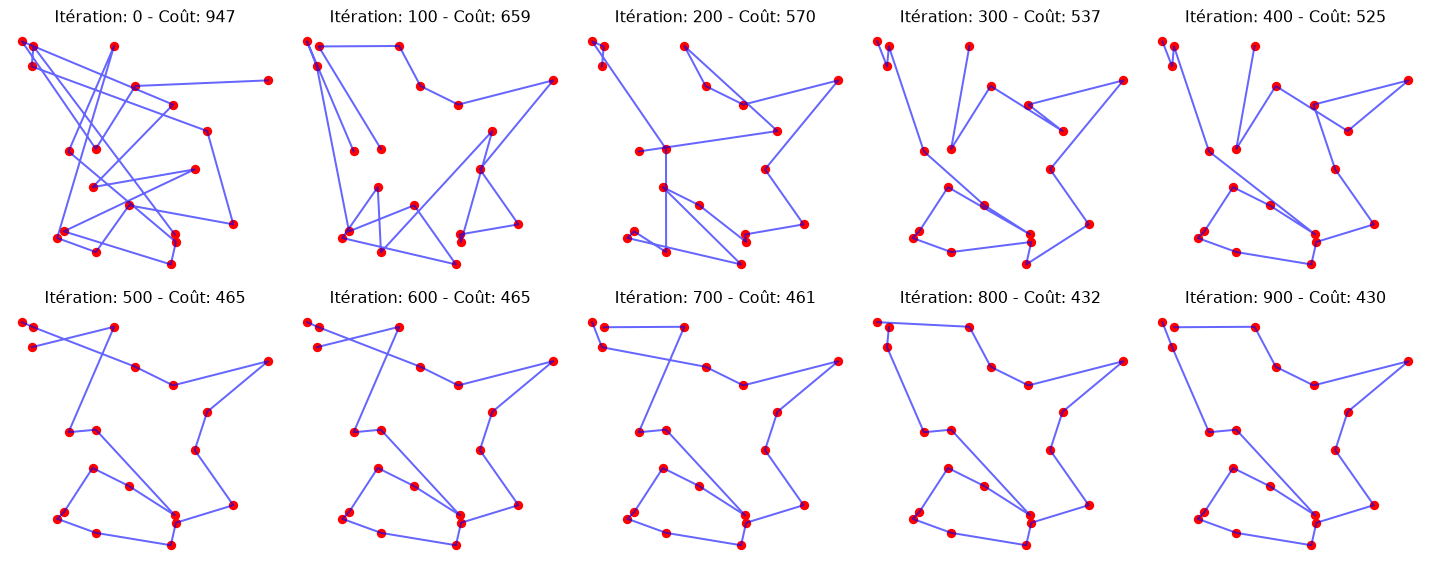

In [47]:
# Plot the final best route
get_neighbor = get_neighbor_swap

best_route, best_cost, temperatures, costs = simulated_annealing(distance_matrix, initial_temp, cooling_rate, max_iterations)

## Meilleur chemin

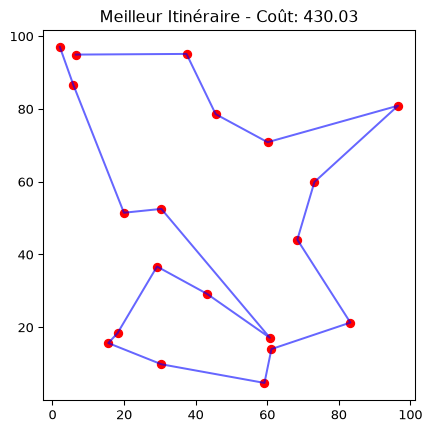

In [48]:
# Plot the final best route
plt.figure(figsize=(5, 5))
plt.scatter(*zip(*coordinates), c='red', marker='o')
plt.plot(*zip(*coordinates[best_route]), 'b-', alpha=0.6)
plt.title(f"Meilleur Itinéraire - Coût: {best_cost:.2f}")
plt.show()

Dans ce cas précis et pour le problème donné, la **réversion de
segment** (coût = 386,43) s’est avérée plus efficace par rapport à
l’**échange de voisins** (coût = 430,03).

## Température et coût

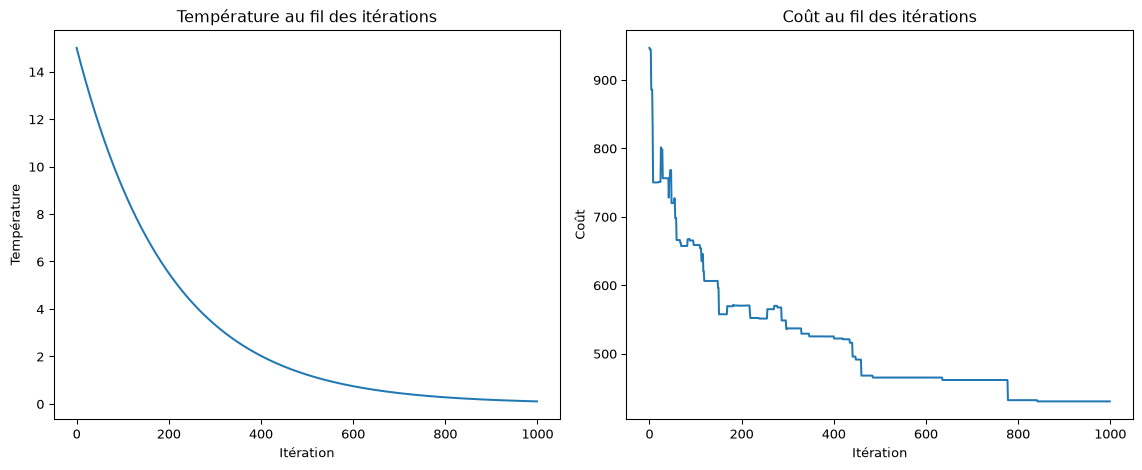

In [49]:
# Plot temperature and cost graphs
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(temperatures)
plt.title("Température au fil des itérations")
plt.xlabel("Itération")
plt.ylabel("Température")
plt.subplot(1, 2, 2)

plt.plot(costs)
plt.title("Coût au fil des itérations")
plt.xlabel("Itération")

plt.ylabel("Coût")
plt.tight_layout()
plt.show()

## Sélection d’une stratégie de voisinage

- **Mouvements simples (échange, insertion)** : Efficaces pour
  l’exploration initiale ; risque d’être piégé dans des optima locaux.

- **Mouvements complexes** : Améliorent la capacité à échapper aux
  optima locaux et accélèrent la convergence ; impliquent un coût
  computationnel plus élevé.

- **Approches hybrides** : Intégrer diverses stratégies pour la
  génération de voisinage. Utiliser des mouvements simples au début, en
  passant à des mouvements complexes à mesure que la convergence
  progresse.

## Température initiale

**Influence** : Étant donné que la probabilité d’accepter un nouvel état
est donnée par $e^{-\frac{\Delta E}{T}}$, la sélection de la
**température initiale** est directement influencée par $\Delta E$ et
donc par la **valeur de la fonction objectif pour un état aléatoire**,
$f(s)$.

## Température initiale

- **Problèmes exemple** : Considérons deux scénarios : le problème $a$
  avec $f(a) = 1,000$ et le problème $b$ avec $f(b) = 100$.

- **Différence d’énergie** : Accepter un état 10 % pire entraîne des
  différences d’énergie de $\Delta E = 0.1 \cdot f(a) = 100$ pour le
  problème $a$ et $\Delta E = 0.1 \cdot f(b) = 10$ pour le problème $b$.

- **Probabilité d’acceptation** : Pour accepter un tel état 60 % du
  temps, on fixe $e^{-\frac{\Delta E}{T}} = 0.6$. La résolution pour $T$
  donne des températures initiales d’environ $T \approx 195.8$ pour le
  problème $a$ et $T \approx 19.58$ pour le problème $b$.

## Température initiale

Une **approche populaire** consiste à définir la température initiale de
sorte qu’une **portion significative des mouvements (souvent autour de
60-80%) soit acceptée**.

Cela peut être réalisé en exécutant une phase préliminaire où la
température est ajustée jusqu’à ce que le ratio d’acceptation se
stabilise dans cette plage.

Ben-Ameur (2004) propose une méthodologie mathématique plus rigoureuse.

## Stratégies de refroidissement

Dans le cadre du **recuit simulé**, le refroidissement est essentiel
pour gérer la convergence de l’algorithme. Le calendrier de
refroidissement détermine le taux de diminution de la température,
influençant ainsi la capacité de l’algorithme à **échapper aux optima
locaux** et à **converger vers une solution quasi-optimale**.

Nourani et Andresen (1998) et Alex et al. (2017)

## Refroidissement linéaire

- **Description** : La température diminue linéairement à chaque
  itération.
- **Formule** : $T = T_0 - \alpha \cdot k$
  - $T_0$ : Température initiale
  - $\alpha$ : Un décrément constant
  - $k$ : Itération actuelle
- **Avantages** : Simple à mettre en œuvre et à comprendre.
- **Inconvénients** : Conduit souvent à une **convergence prématurée**
  car la température diminue trop rapidement.

In [50]:
temperature = initial_temp - alpha * iteration

## Refroidissement géométrique

- **Description** : La température diminue de manière exponentielle à
  chaque itération.
- **Formule** : $T = T_0 \cdot \alpha^k$
  - $\alpha$ : Taux de refroidissement, généralement entre 0,8 et 0,99
  - $k$ : Itération actuelle
- **Avantages** : Largement utilisé pour sa simplicité et son
  efficacité.
- **Inconvénients** : Le choix de $\alpha$ est crucial ; s’il est trop
  petit, la température baisse trop rapidement, et s’il est trop grand,
  la convergence peut être lente.

In [51]:
temperature = initial_temp * (cooling_rate ** iteration)

## Refroidissement logarithmique

- **Description** : La température diminue lentement selon une fonction
  logarithmique.
- **Formule** : $T = \frac{\alpha \cdot T_0}{\log(1+k)}$
  - $\alpha$ : Une constante de mise à l’échelle
  - $k$ : Itération actuelle
- **Avantages** : Offre un taux de refroidissement plus lent, utile pour
  les problèmes nécessitant une exploration approfondie de l’espace de
  solution.
- **Inconvénients** : La convergence peut être très lente, nécessitant
  de nombreuses itérations.

In [52]:
temperature = alpha * initial_temp / (np.log(1 + iteration))

## Refroidissement inverse

- **Description** : La température diminue selon une fonction inverse du
  numéro d’itération.
- **Formule** : $T = \frac{T_0}{1+\alpha \cdot k}$
  - $\alpha$ : Une constante de mise à l’échelle
  - $k$ : Itération actuelle
- **Avantages** : Permet un processus de refroidissement plus contrôlé,
  équilibrant exploration et exploitation.
- **Inconvénients** : Peut nécessiter un ajustement minutieux de
  $\alpha$ pour être efficace.

In [53]:
temperature = initial_temp / (1 + alpha * iteration)

## Refroidissement adaptatif

- **Description** : Le calendrier de refroidissement est ajusté
  dynamiquement en fonction des performances de l’algorithme.
- **Stratégie** : Si l’algorithme ne progresse pas de manière
  significative, le taux de refroidissement peut être ralenti.
  Inversement, si le progrès est régulier, le taux de refroidissement
  peut être accéléré.
- **Avantages** : Plus flexible et peut s’adapter aux caractéristiques
  du problème.
- **Inconvénients** : Plus complexe à mettre en œuvre et nécessite une
  conception minutieuse pour éviter l’instabilité.

In [54]:
if no_significant_change_in_cost:
    temperature *= 0.99 # Ralentir le refroidissement
else:
    temperature *= 0.95 # Accélérer le refroidissement

## Stratégies de refroidissement

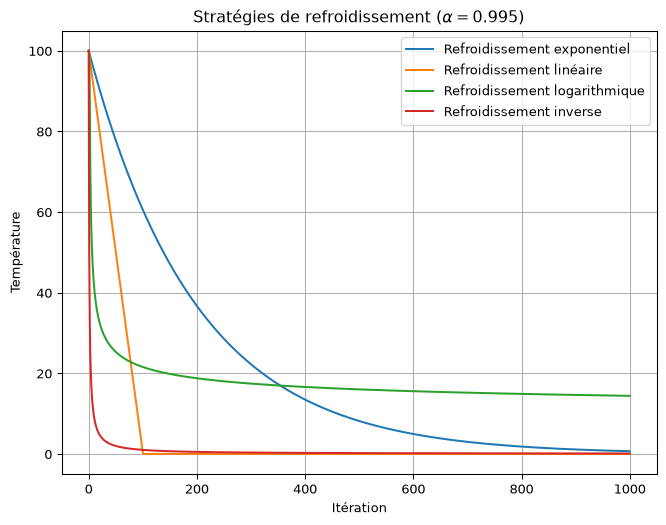

In [55]:
# Constants
initial_temp = 100
alpha = 0.995
iterations = np.arange(0, 1001)

# Cooling strategies
def exponential_cooling(initial_temp, alpha, iteration):
    return initial_temp * (alpha ** iteration)

def linear_cooling(initial_temp, alpha, iteration):
    return max(0, initial_temp - alpha * iteration)

def logarithmic_cooling(initial_temp, alpha, iteration):
    return min(initial_temp, alpha * initial_temp / (np.log(1 + iteration) + 10e-9))

def inverse_cooling(initial_temp, alpha, iteration):
    return initial_temp / (1 + alpha * iteration)

# Calculate temperatures
linear_temps = [linear_cooling(initial_temp, alpha, i) for i in iterations]
exponential_temps = [exponential_cooling(initial_temp, alpha, i) for i in iterations]
logarithmic_temps = [logarithmic_cooling(initial_temp, alpha, i) for i in iterations]
inverse_temps = [inverse_cooling(initial_temp, alpha, i) for i in iterations]

# Plotting
plt.figure(figsize=(8, 6))
plt.plot(iterations, exponential_temps, label='Refroidissement exponentiel')
plt.plot(iterations, linear_temps, label='Refroidissement linéaire')
plt.plot(iterations, logarithmic_temps, label='Refroidissement logarithmique')
plt.plot(iterations, inverse_temps, label='Refroidissement inverse')
plt.xlabel('Itération')
plt.ylabel('Température')
plt.title(r'Stratégies de refroidissement ($\alpha = 0.995$)')
plt.legend()
plt.grid(True)
plt.show()

**Voir aussi** : [Effective Simulated Annealing with
Python](https://nathanrooy.github.io/posts/2020-05-14/simulated-annealing-with-python/)
par Nathan A. Rooy, 2024-11-05.

## Choisir la bonne stratégie

- **Spécifique au problème** : Le choix du calendrier de refroidissement
  dépend souvent des caractéristiques du problème à résoudre. Certains
  problèmes bénéficient d’un taux de refroidissement plus lent, tandis
  que d’autres peuvent nécessiter une convergence plus rapide.

- **Expérimentation** : Il est courant d’expérimenter différentes
  stratégies et paramètres pour trouver le meilleur équilibre entre
  exploration (recherche large) et exploitation (affinement des
  meilleures solutions actuelles).

## Conclusion

Après l’application du **recuit simulé**, une méthode de **recherche
locale** comme la **montée de colline** peut être utilisée pour
**affiner la solution**.

. . .

Le **recuit simulé** est efficace pour explorer l’espace de solutions et
**éviter les minima locaux**, tandis que la **recherche locale** se
concentre sur l’**exploration des solutions voisines de celle obtenue**.

## Visualisation du recuit simulé

<https://youtu.be/NPE3zncXA5s?si=Z9rk2Kt_5pN8ChlA>

**Attribution:**
[ComputationalScientist](https://www.youtube.com/@computationalscientist6368),
publié le 06-01-2018.

# Prologue

## Résumé

- Les algorithmes de recherche locale se concentrent sur la recherche
  d’états objectifs en se déplaçant entre des états voisins sans suivre
  les chemins.
- L’algorithme de montée de colline recherche le voisin de plus grande
  valeur mais peut se retrouver coincé dans des maxima locaux ou des
  plateaux.
- Une représentation efficace de l’état, comme l’utilisation de
  permutations dans le problème des 8-Reines, évite les placements
  illégaux et améliore les performances.
- Le recuit simulé permet des déplacements occasionnels vers le haut
  pour échapper aux optima locaux, contrôlés par un paramètre de
  température décroissant.
- La probabilité d’acceptation dans le recuit simulé diminue à mesure
  que la température baisse et que la différence d’énergie augmente.
- Le recuit simulé résout efficacement des problèmes complexes comme le
  problème du voyageur de commerce en explorant l’espace des solutions
  de manière probabiliste.

## Lectures complémentaires

![](https://media.springernature.com/full/springer-static/cover-hires/book/978-3-319-91086-4?as=webp.png)

“La méthodologie globale du recuit simulé \[simulated annealing\] est
ensuite déployée en détail sur une application réelle : un **problème de
planification de trajectoire aérienne à grande échelle impliquant près
de 30 000 vols** à l’échelle continentale européenne.”

(Gendreau et Potvin 2019, chap. 1)

Gendreau et Potvin (2019), [accès via Springer
Link](https://link.springer.com/book/10.1007/978-3-319-91086-4).

Saviez-vous que vous pouvez accéder gratuitement à l’ensemble de la
collection de livres de Springer ? En utilisant un appareil connecté à
une adresse IP de l’uOttawa et en visitant [Springer
Link](https://link.springer.com), vous avez la possibilité de
télécharger des livres en format PDF ou EPUB.

Le livre est co-édité par [Jean-Yves
Potvin](https://recherche.umontreal.ca/english/our-researchers/professors-directory/researcher/is/in14464/)
et [Michel
Gendreau](https://www.polymtl.ca/expertises/en/gendreau-michel).
[Jean-Yves
Potvin](https://recherche.umontreal.ca/english/our-researchers/professors-directory/researcher/is/in14464/)
est professeur à l’Université de Montréal, tandis que [Michel
Gendreau](https://www.polymtl.ca/expertises/en/gendreau-michel) est
professeur à l’École Polytechnique de Montréal.

## Prochain cours

- Nous discuterons des algorithmes basés sur la population.

## Références

Aarts, E. H. L., et J. H. M. Korst. 1989. *Simulated annealing and
Boltzmann machines : a stochastic approach to combinatorial optimization
and neural computing*. Wiley-Interscience series in discrete mathematics
et optimization. Wiley.

Alex, Kwaku Peprah, Kojo Appiah Simon, et Kwame Amponsah Samuel. 2017.
« An Optimal Cooling Schedule Using a Simulated Annealing Based
Approach ». *Applied Mathematics* 08 (08): 1195‑210.
<https://doi.org/10.4236/am.2017.88090>.

Bellman, Richard. 1962. « Dynamic Programming Treatment of the
Travelling Salesman Problem ». *Journal of the ACM (JACM)* 9 (1): 61‑63.
<https://doi.org/10.1145/321105.321111>.

Ben-Ameur, Walid. 2004. « Computing the Initial Temperature of Simulated
Annealing ». *Computational Optimization and Applications* 29 (3):
369‑85. <https://doi.org/10.1023/b:coap.0000044187.23143.bd>.

Gendreau, M., et J. Y. Potvin. 2019. *Handbook of Metaheuristics*.
International Series in Operations Research & Management Science.
Springer International Publishing.
<https://books.google.com.ag/books?id=RbfFwQEACAAJ>.

Held, Michael, et Richard M. Karp. 1962. « A Dynamic Programming
Approach to Sequencing Problems ». *Journal of the Society for
Industrial and Applied Mathematics* 10 (1): 196‑210.
<https://doi.org/10.1137/0110015>.

Laarhoven, P. J. M., et E. H. L. Aarts. 1987. *Simulated annealing:
theory and applications*. Kluwer Academic Publishers.

Nourani, Yaghout, et Bjarne Andresen. 1998. « A comparison of simulated
annealing cooling strategies ». *Journal of Physics A: Mathematical and
General* 31 (41): 8373.

Russell, Stuart, et Peter Norvig. 2020. *Artificial Intelligence: A
Modern Approach*. 4ᵉ éd. Pearson. <http://aima.cs.berkeley.edu/>.

## Prochain cours

- Nous discuterons des algorithmes basés sur les populations.

## Références

Aarts, E. H. L., et J. H. M. Korst. 1989. *Simulated annealing and
Boltzmann machines : a stochastic approach to combinatorial optimization
and neural computing*. Wiley-Interscience series in discrete mathematics
et optimization. Wiley.

Alex, Kwaku Peprah, Kojo Appiah Simon, et Kwame Amponsah Samuel. 2017.
« An Optimal Cooling Schedule Using a Simulated Annealing Based
Approach ». *Applied Mathematics* 08 (08): 1195‑210.
<https://doi.org/10.4236/am.2017.88090>.

Bellman, Richard. 1962. « Dynamic Programming Treatment of the
Travelling Salesman Problem ». *Journal of the ACM (JACM)* 9 (1): 61‑63.
<https://doi.org/10.1145/321105.321111>.

Ben-Ameur, Walid. 2004. « Computing the Initial Temperature of Simulated
Annealing ». *Computational Optimization and Applications* 29 (3):
369‑85. <https://doi.org/10.1023/b:coap.0000044187.23143.bd>.

Gendreau, M., et J. Y. Potvin. 2019. *Handbook of Metaheuristics*.
International Series in Operations Research & Management Science.
Springer International Publishing.
<https://books.google.com.ag/books?id=RbfFwQEACAAJ>.

Held, Michael, et Richard M. Karp. 1962. « A Dynamic Programming
Approach to Sequencing Problems ». *Journal of the Society for
Industrial and Applied Mathematics* 10 (1): 196‑210.
<https://doi.org/10.1137/0110015>.

Laarhoven, P. J. M., et E. H. L. Aarts. 1987. *Simulated annealing:
theory and applications*. Kluwer Academic Publishers.

Nourani, Yaghout, et Bjarne Andresen. 1998. « A comparison of simulated
annealing cooling strategies ». *Journal of Physics A: Mathematical and
General* 31 (41): 8373.

Russell, Stuart, et Peter Norvig. 2020. *Artificial Intelligence: A
Modern Approach*. 4ᵉ éd. Pearson. <http://aima.cs.berkeley.edu/>.

------------------------------------------------------------------------

Marcel **Turcotte**

<Marcel.Turcotte@uOttawa.ca>

École de **science informatique** et de génie électrique (**SI**GE)

Université d’Ottawa